# Figures for "Reactivating Targeted Fault Interfaces Using Pre-conditioning in Complex Fault Zones"

Reproduces the model figures of the paper from the post-processed outputs
(`F_clean.parquet`, one per model, produced by `postprocessing/reformat_output.py`).
Run the cells top to bottom; each `## Fig.` section is self-contained after the setup cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os
import matplotlib.ticker as ticker 
from pathlib import Path
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import re
import matplotlib.gridspec as gridspec


# plotting format
plt.rcParams.update({
    'font.size': 12,            # General font size
    'axes.labelsize': 16,       # Axis labels
    'xtick.labelsize': 12,      # X tick labels
    'ytick.labelsize': 12,      # Y tick labels
    'legend.fontsize': 12,      # Legend text
    'figure.titlesize': 12,      # Figure title
    'font.family': 'Arial', 
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'lines.linewidth': 1.5
})

In [2]:
# Paths (relative to this notebook). Download the archived data first; see ../model_outputs/README.md and ../field_data/README.md
DATA_DIR = Path('../model_outputs')   # <model>/F_clean.parquet for each model
FIELD_DIR = Path('../field_data')     # FEAR-1 stimulation records (Fig. 2)
MODEL_DIR = Path('../models_code')              # model inputs (00_mesh/MESH_o_heterf, Fig. 2)

SAVE_FIG = True
FIG_DIR = Path('output')                   # exported figures
FIG_DIR.mkdir(exist_ok=True)


# Results figures

## Fig.1 FEAR-1 Test14 data

In [3]:
def smart_time_formatter(x, pos=None):
    dt = mdates.num2date(x)

    time_str = dt.strftime("%H:%M")

    # show date only at midnight (or first tick of a new day)
    if dt.hour == 0 and dt.minute == 0:
        return f"{time_str}\n{dt.strftime('%b %d, %Y')}"
    else:
        return time_str

In [4]:
# Load CSV
df_s = pd.read_csv(FIELD_DIR / 'FEAR1_seismicity.csv')  

# Convert time column
df_s["Time"] = pd.to_datetime(df_s["Time"])

# Clean numeric column
df_s["total number of events"] = pd.to_numeric(
    df_s["total number of events"],
    errors="coerce"
)

df_s["magnitude_MwA.max"] = pd.to_numeric(
    df_s["magnitude_MwA.max"],
    errors="coerce"
)

df_s["event rate"] = pd.to_numeric(
    df_s["event rate"],
    errors="coerce"
)

# df_s

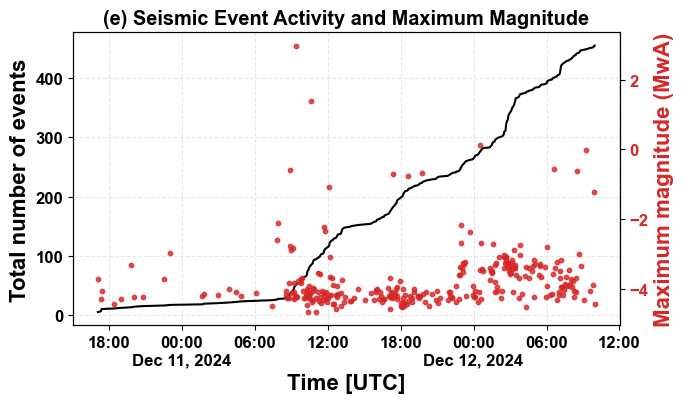

In [5]:
# --------------------------------------------------
# Prepare data
# --------------------------------------------------

df_plot = df_s.copy()

df_plot["Time"] = pd.to_datetime(
    df_plot["Time"],
    errors="coerce"
)

df_plot["total number of events"] = pd.to_numeric(
    df_plot["total number of events"],
    errors="coerce"
)

df_plot["magnitude_MwA.max"] = pd.to_numeric(
    df_plot["magnitude_MwA.max"],
    errors="coerce"
)

# Sort by time
df_plot = df_plot.sort_values("Time")
# Remove rows without a time
df_plot = df_plot.dropna(subset=["Time"])


fig, ax1 = plt.subplots(figsize=(7, 4.2))

# --------------------------------------------------
# Total number of events
# --------------------------------------------------

data_events = df_plot.dropna(
    subset=["total number of events"]
)

line1 = ax1.plot(
    data_events["Time"],
    data_events["total number of events"],
    label="Total number of events",
    color = 'k'
)

ax1.set_xlabel("Time [UTC]")
ax1.set_ylabel("Total number of events")


# --------------------------------------------------
# Maximum magnitude -- dots
# --------------------------------------------------

ax2 = ax1.twinx()

data_mag = df_plot.dropna(
    subset=["magnitude_MwA.max"]
)

scatter = ax2.scatter(
    data_mag["Time"],
    data_mag["magnitude_MwA.max"],
    s=10,
    alpha=0.8,
    color="tab:red",
    label="Maximum magnitude"
)

ax2.set_ylabel(
    "Maximum magnitude (MwA)",
    color="tab:red"
)

ax2.tick_params(axis='y', labelcolor="tab:red")

# ax2.set_ylim([-5, 1])


# --------------------------------------------------
# Time axis
# --------------------------------------------------
ax1.xaxis.set_major_formatter(FuncFormatter(smart_time_formatter))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))

# --------------------------------------------------
# Grid
# --------------------------------------------------

ax1.grid(
    True,
    alpha=0.3,
    linestyle="--"
)

# Keep grid behind data
ax1.set_axisbelow(True)


# --------------------------------------------------
# Combined legend
# --------------------------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.tick_params(axis="both")
ax2.tick_params(axis="y")

plt.title("(e) Seismic Event Activity and Maximum Magnitude")

fig.tight_layout()

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig1_e_seis.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

In [6]:
# Load CSV
df_ir_o = pd.read_csv(FIELD_DIR / 'FEAR1_injection_flow_rate.csv')  
df_ip_o = pd.read_csv(FIELD_DIR / 'FEAR1_pressure_BFE05.csv') 

# Convert time column
df_ir_o["Time"] = pd.to_datetime(df_ir_o["Time"])
df_ip_o["Time"] = pd.to_datetime(df_ip_o["Time"])

# Convert time column
cutoff = pd.Timestamp("2024-12-10 17:00:00")
cutoff1 = pd.Timestamp("2024-12-12 10:00:00")

df_ir = df_ir_o[df_ir_o["Time"].between(cutoff, cutoff1, inclusive="neither")].copy()
df_ip = df_ip_o[df_ip_o["Time"].between(cutoff, cutoff1, inclusive="neither")].copy()

# Clean numeric column
df_ir["flow_rate"] = (
    df_ir["flow_pumps_A_l_min.first"]
    .astype(float)
)

df_ip["Pressure(bar)"] = (
    df_ip["1_P2.mean"]
    .astype(float)
)

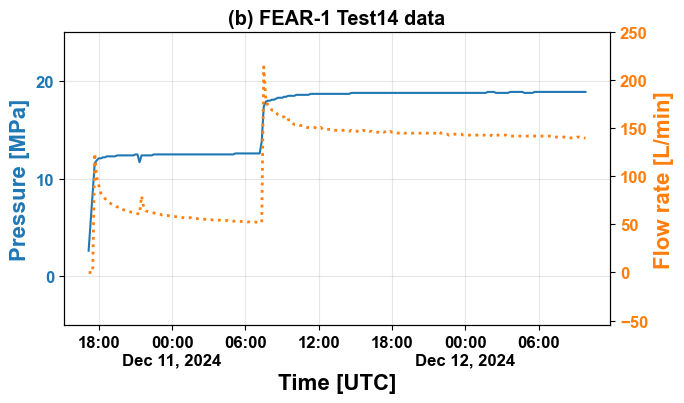

In [7]:
# Create figure
fig, ax1 = plt.subplots(figsize=(7, 4.2))

# Pressure axis
ax1.plot(
    df_ip["Time"],
    df_ip["Pressure(bar)"]*0.1,
    color="tab:blue",
    linewidth=1.5,
    label="Injection Pressure"
)

ax1.set_ylabel("Pressure [MPa]", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_ylim([-5, 25])
ax1.set_yticks(np.arange(0, 26, 10))

# Flow axis
ax2 = ax1.twinx()

ax2.plot(
    df_ir["Time"],
    df_ir["flow_rate"],
    color="tab:orange",
    linestyle=":",
    linewidth=2,
    label="Injection rate"
)

ax2.set_ylabel("Flow rate [L/min]", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")
# ax2.set_ylim([-55, 350])
ax2.set_ylim([-55, 250])
ax2.set_yticks(np.arange(-50, 260, 50))

# Labels
ax1.set_xlabel("Time [UTC]")

# Grid
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

ax1.xaxis.set_major_formatter(FuncFormatter(smart_time_formatter))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))

plt.title('(b) FEAR-1 Test14 data')
plt.tight_layout()

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig1_b_injec.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.2 Data-constrained permeability evolution

### plot the injection point -- pore pressure and injection rate

In [3]:
# Time arrays
t1 = np.linspace(0, 48, 500)

# Step functions for each injection rate
injection_rate_1 = np.piecewise(t1, [t1 <= 24, t1 > 24], [0, 150])
injection_rate_2 = np.piecewise(t1, [t1 <= 24, t1 > 24], [50, 150])

In [4]:
# File paths
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

fault_map = {7: '(middle / injection)', 6: '(right)', 5: '(left)'} 
cell_map = {7: 'ASX79', 6: 'AU585',  5: 'ARQ70'} 

lay_num = 7
cell = cell_map.get(lay_num)
inj_point_F = F_df[F_df['ELEM'] == cell]  
inj_point_F_np = F_df_np[F_df_np['ELEM'] == cell]  

In [5]:
# Keep the original first row
first_row = inj_point_F_np.iloc[[0]].copy()

# Duplicate the first row and set its Time to 24 hours
second_row = inj_point_F_np.iloc[[0]].copy()
second_row['Time'] = 24 * 3600

# Keep rows with Time >= 400 and shift by 24 hours
filtered = inj_point_F_np[inj_point_F_np['Time'] >= 400].copy()
filtered['Time'] -= (400 - 24 * 3600)

# Combine them
inj_point_F_np = pd.concat(
    [first_row, second_row, filtered], ignore_index=True
)

# inj_point_F_np.head()

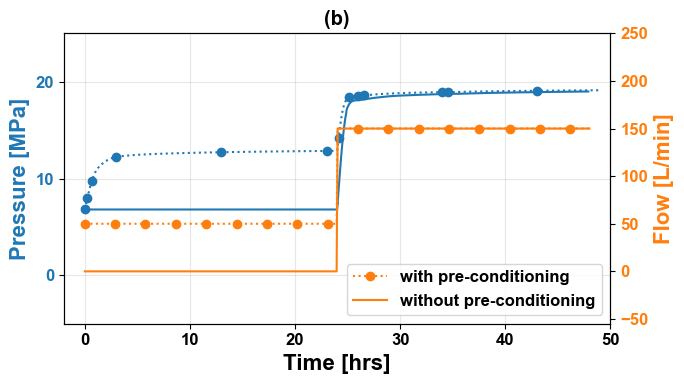

In [6]:
# Create figure
fig, ax1 = plt.subplots(figsize=(7, 4))

# Pressure axis
ax1.plot(
    inj_point_F['Time'] / 3600,
    inj_point_F['Pressure(Pa)'] / 1e6,
    color='tab:blue',
    linestyle=':', marker='o', markevery=10
)

ax1.plot(
    inj_point_F_np['Time'] / 3600 ,
    inj_point_F_np['Pressure(Pa)'] / 1e6,
    color='tab:blue'
)

ax1.set_ylabel("Pressure [MPa]", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_ylim([-5, 25])
ax1.set_yticks(np.arange(0, 26, 10))

# Flow axis
ax2 = ax1.twinx()

ax2.plot(t1, injection_rate_2, marker='o', markevery=30, linestyle=':', label="with pre-conditioning", color="tab:orange")
ax2.plot(t1, injection_rate_1, label="without pre-conditioning", color="tab:orange")

ax2.set_ylabel("Flow [L/min]", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")
# ax2.set_ylim([-55, 350])
ax2.set_ylim([-55, 250])
ax2.set_yticks(np.arange(-50, 260, 50))

# Labels
ax1.set_xlim([-2, 50])
ax1.set_xlabel("Time [hrs]")

# Grid
ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower right"
)


plt.title('(b)')
plt.tight_layout()

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig2_b_ModelInjec.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

### plot the lognormal distribution

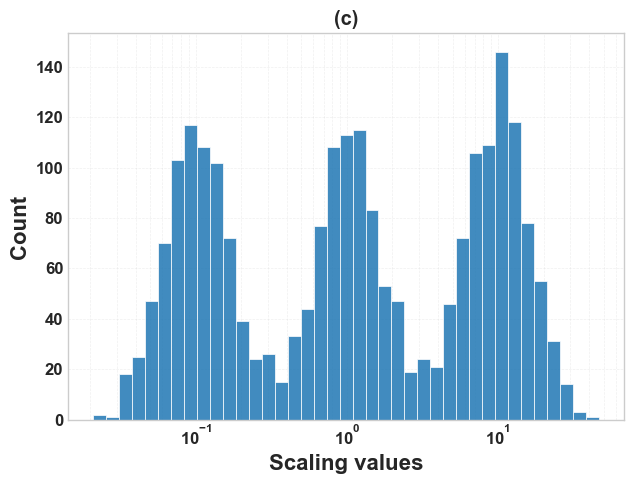

In [7]:
df_mesh = pd.read_csv(MODEL_DIR / '00_mesh' / 'MESH_o_heterf')

pattern = re.compile(
    r'(\S+)\s+'          # A11
    r'(\d+)\s+'          # 0
    r'([A-Z]+)'          # FRONB
    r'([+-]?\d+\.\d+e[+-]?\d+)\s+'   # 2.9481e+51
    r'([+-]?\d+\.\d+E[+-]?\d+)'      # 1.0000E+00
    r'([+-]?\d+\.\d+e[+-]?\d+)\s+'   # -1.758e+01
    r'([+-]?\d+\.\d+)\s*'            # -247.375
    r'([+-]?\d+\.\d+e[+-]?\d+)'      # -6.215e+01
)

rows = []

with open(MODEL_DIR / '00_mesh' / 'MESH_o_heterf') as f:
    next(f)  # skip header
    for line in f:
        m = pattern.search(line)
        if m:
            rows.append(m.groups())

df = pd.DataFrame(
    rows,
    columns=[
        "element", "index", "region",
        "v1", "v2", "v3", "v4", "v5"
    ]
)

# convert numeric columns
for col in ["index", "v1", "v2", "v3", "v4", "v5"]:
    df[col] = pd.to_numeric(df[col])

# only plot the disctribution for the fault zone
df_plot = df[df['region'].isin(['INTEM','INTER','INTEL','COREM','CORER','COREL'])].copy()

v2 = df_plot["v2"].astype(float)

# log-binned histogram (correct for lognormal-style data)
bins = np.logspace(np.log10(v2.min()), np.log10(v2.max()), 40)

with plt.style.context("seaborn-v0_8-whitegrid"):
    plt.figure(figsize=(6.5, 5))

    plt.hist(v2, bins=bins, edgecolor="white", linewidth=0.6, alpha=0.85)

    plt.xscale("log")

    plt.xlabel("Scaling values")
    plt.ylabel("Count")
    plt.title("(c)")

    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.3)

    plt.tight_layout()

    if SAVE_FIG:
        save_path = FIG_DIR / 'Fig2_c_scaling.pdf'

        fig.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            dpi=600
        )

    plt.show()

### permeability structures

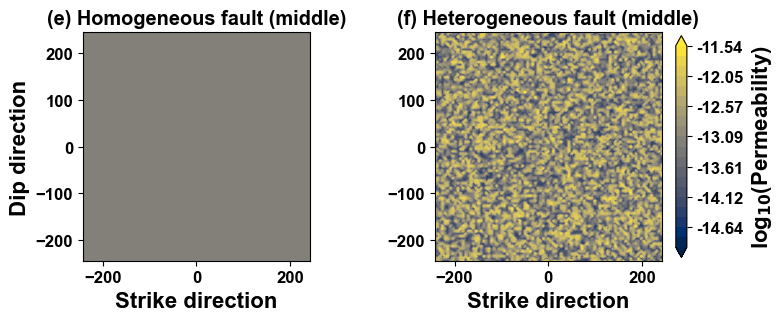

In [8]:
# ---------------- DATA ----------------
# reading the data
# File paths
base_path = (DATA_DIR / '03_heterf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

lay_num = 7
F_intem = F_df[F_df['ROCK']==lay_num]

subset = F_intem.loc[F_intem["Time"] == 0.0].reset_index(drop=True)

mu = np.log10(subset["K_x"].astype(float).to_numpy())
y = subset["Y"].to_numpy()
z = subset["Z"].to_numpy()

# ---------------- GRID ----------------
ny, nz = 500, 500
y_grid, z_grid = np.meshgrid(
    np.linspace(y.min(), y.max(), ny),
    np.linspace(z.min(), z.max(), nz)
)

# ---------------- INTERPOLATION ----------------
mu_interp = griddata(
    points=(y, z),
    values=mu,
    xi=(y_grid, z_grid),
    method="linear"
)

# Optional: mask invalid regions for cleaner plots
mu_interp = np.ma.masked_invalid(mu_interp)

# homogeneous reference (keep consistent dtype)
homog_mu = np.full_like(mu_interp, np.log10(6.0e-14))

# ---------------- COLOR SCALE (IMPORTANT FIX) ----------------
vmin = np.nanmin(mu_interp)
vmax = np.nanmax(mu_interp)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
levels = np.linspace(vmin, vmax, 21)

# ---------------- PLOT ----------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4.8), constrained_layout=False)
fig.subplots_adjust(wspace=0.55)

titles = ["(e) Homogeneous fault (middle)", "(f) Heterogeneous fault (middle)"]
fields = [homog_mu, mu_interp]

for ax, field, title in zip(axes, fields, titles):
    if title == "(e) Homogeneous fault (middle)":
        ax.set_ylabel("Dip direction")
    cf = ax.contourf(
        y_grid, z_grid, field,
        levels=levels,
        cmap="cividis",
        norm=norm,
        extend="both"
    )
    ax.set_title(title)
    ax.set_xlabel("Strike direction")
    ax.set_aspect("equal")


# ---------------- COLORBAR ----------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label(r"log$_{10}$(Permeability)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig2_ef_k.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.3 Pre-conditioning on the single permeable fault

In [3]:
# Time arrays
t1 = np.linspace(0, 28, 500)

# Step functions for each injection rate
injection_rate_1 = np.piecewise(t1, [t1 <= 24, t1 > 24], [0.4 * 60, 1.2 *60])
injection_rate_2 = np.piecewise(t1, [t1 <= 24, t1 > 24], [0.00, 1.2*60])

In [4]:
# reading the data
# File paths
base_path = (DATA_DIR / '01_base')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

base_path = (DATA_DIR / '01_base_np')
flac_file = base_path / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file, engine='pyarrow')

# cut it, because the simulations run for longer time to check the pore pressure fit
F_df = F_df[F_df['Time'] <= 28*3600].copy()
F_df_np = F_df_np[F_df_np['Time'] <= 4*3600+400].copy()

In [5]:
def compute_rupture_area(df, time_col='Time', strain_col='Strain_P', vol_col='Vol_zone', thickness=0.6):
    """
    Compute a magnitude series from a DataFrame based on strain and volume zone.

    Parameters:
    - df : pd.DataFrame
        Input dataframe containing the relevant columns.
    - time_col : str
        Column name for time steps.
    - strain_col : str
        Column name for strain values.
    - vol_col : str
        Column name for volume values.
    - thickness : float
        Thickness of the fault interface -> get the area from the volume

    Returns:
    - ra : np.ndarray
        Array containing area for positive strain at each time step.
    """
    work_df = df.copy()
    time_steps = work_df[time_col].unique()
    ra = np.full(time_steps.shape, np.nan)

    for i, t in enumerate(time_steps):
        subset = work_df[work_df[time_col] == t].reset_index(drop=True)
        slipmask_now = subset[strain_col] > 0.0
        A = subset.loc[slipmask_now, vol_col].astype(float).to_numpy() / thickness
        ra[i] = np.sum(A)

    return ra

In [6]:
fault_map = {7: '(middle / injection)', 6: '(right)', 5: '(left)'} 
cell_map = {7: 'ASX79', 6: 'AU585',  5: 'ARQ70'}

lay_num = 7
cell = cell_map.get(lay_num)
inj_point_F = F_df[F_df['ELEM'] == cell]  
inj_point_F_np = F_df_np[F_df_np['ELEM'] == cell]  

# Keep the original first row
first_row = inj_point_F_np.iloc[:2]
# Keep rows with Time >= 400
filtered = inj_point_F_np[inj_point_F_np['Time'] >= 400].copy()
filtered['Time'] -= (400 - 24 * 3600)
# Combine them
inj_point_F_np = pd.concat([first_row, filtered], ignore_index=True)
inj_point_F_np.loc[1,'Time'] += 86400
# inj_point_F_np.head()

In [7]:
F_intem = F_df[F_df['ROCK']==7]
F_intem_np = F_df_np[F_df_np['ROCK']==7] 

# %%
# Compute rupture areas for no pre-conditioning
ra_intem = compute_rupture_area(F_intem)
ra_times = np.unique(F_intem['Time']) / 3600

ra_np = compute_rupture_area(F_intem_np)
ra_np_times = np.unique(F_intem_np['Time'])  # unit: hour
time_zero = np.arange(24) * 3600  # seconds
mask = ra_np_times > 400
# Extend time to cover shifted events beyond 400 seconds
time_extended = np.concatenate([time_zero, ra_np_times[mask] - 400 + 24*3600]) / 3600
ra_np_extended = np.concatenate([np.zeros(24), ra_np[mask]])

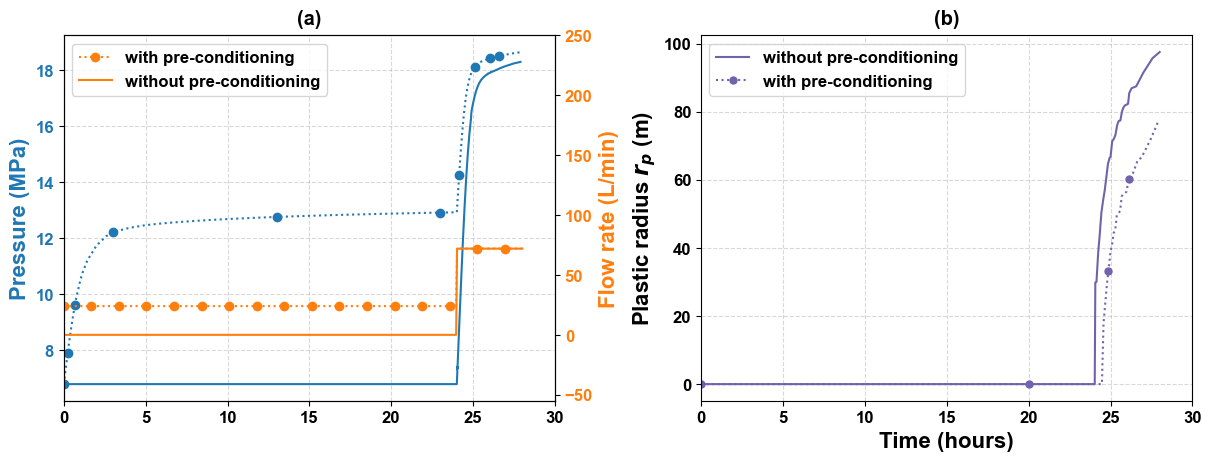

In [8]:
# ----------------------------
# Figure and axes
# ----------------------------
fig, (ax0, ax1) = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    constrained_layout=True
)

# ----------------------------
# Styling helper
# ----------------------------
def style(ax):
    ax.grid(True, color='gray', alpha=0.3, linestyle='--')
    ax.tick_params(direction='out')

# ============================
# (a) Injection protocol
# ============================
ax = ax0

# Pressure
ax.plot(
    inj_point_F['Time'] / 3600,
    inj_point_F['Pressure(Pa)'] / 1e6,
    color='tab:blue',
    linestyle=':',
    marker='o',
    markevery=10,
    label='with pre-conditioning'
)

ax.plot(
    inj_point_F_np['Time'] / 3600,
    inj_point_F_np['Pressure(Pa)'] / 1e6,
    color='tab:blue',
    label='without pre-conditioning'
)

ax.set_title('(a)', pad=8)
ax.set_xlim(0, 30)
ax.set_ylabel('Pressure (MPa)', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
style(ax)

# Flow rate on secondary axis
ax2 = ax.twinx()

ax2.plot(
    t1,
    injection_rate_1,
    color='tab:orange',
    linestyle=':',
    marker='o',
    markevery=30,
    label='with pre-conditioning'
)

ax2.plot(
    t1,
    injection_rate_2,
    color='tab:orange',
    label='without pre-conditioning'
)

ax2.set_ylabel('Flow rate (L/min)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(-55, 250)
ax2.set_yticks(np.arange(-50, 260, 50))
ax2.set_xlabel('Time (hours)')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2, labels2, loc='upper left')

# ============================
# (b) Slipping radius
# ============================
ax = ax1

ax.plot(
    ra_times,
    np.sqrt(ra_intem / np.pi),
    color=cm.Purples(0.7),
    label='without pre-conditioning'
)

ax.plot(
    time_extended,
    np.sqrt(ra_np_extended / np.pi),
    color=cm.Purples(0.7),
    linestyle=':',
    marker='o',
    markevery=20,
    markersize=5,
    label='with pre-conditioning'
)

ax.set_xlim(0, 30)
ax.set_xlabel('Time (hours)')
# ax.set_ylabel('Slipping area radius (m)')
ax.set_ylabel('Plastic radius $r_p$ (m)')
ax.set_title('(b)', pad=8)
ax.legend(loc='upper left')
style(ax)

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig3_sgle_a.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

In [9]:
def get_reactivation_time(df, lay_num, strain_col="Strain_P", threshold=0):
    fault_layer = df[df['ROCK']==lay_num]
    counts = (fault_layer[strain_col] > 0).groupby(fault_layer["Time"]).sum()
    arr = counts.values

    mask = arr > threshold
    if mask.any():
        idx = np.argmax(mask)
        return idx, counts.index[idx], counts
    else:
        return None, None, counts

In [10]:
re_idx, re_t, counts = get_reactivation_time(F_df, 7)
re_idx, re_t_np, counts = get_reactivation_time(F_df_np, 7)

subset = F_intem[F_intem['Time'] == re_t].reset_index(drop=True)
mu = subset['Strain_P'].copy()
# find the area
z_loc = subset['Z'].to_numpy()
y_loc = subset['Y'].to_numpy()
# Define grid (Y and Z swapped)
y_grid, z_grid = np.meshgrid(np.linspace(y_loc.min(), y_loc.max(), 1000),
                            np.linspace(z_loc.min(), z_loc.max(), 1000))
mu_interp = griddata((y_loc, z_loc), mu, (y_grid, z_grid), method='linear')  

subset_np = F_intem_np[F_intem_np['Time'] == re_t_np].reset_index(drop=True)
mu_np = subset_np['Strain_P'].copy()
mu_interp_np = griddata((y_loc, z_loc), mu_np, (y_grid, z_grid), method='linear')  


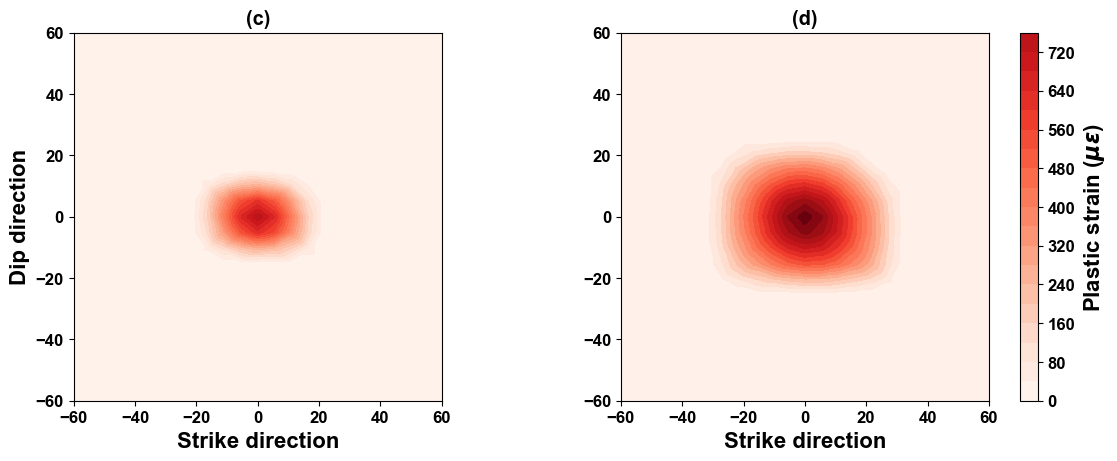

In [11]:
# ----------------------------
# Figure and axes
# ----------------------------

fig, (ax0, ax1) = plt.subplots(
    1, 2,
    figsize=(12, 4.5), # figsize=(10, 4.5),
    constrained_layout=True
)

# ----------------------------
# Common color scale (IMPORTANT)
# ----------------------------
vmin = min(mu_interp.min(), mu_interp_np.min()) * 1e6
vmax = max(mu_interp.max(), mu_interp_np.max()) * 1e6

# ----------------------------
# Contours
# ----------------------------
cf0 = ax1.contourf(
    y_grid, z_grid,
    mu_interp * 1e6,
    levels=20,
    cmap='Reds',
    vmin=vmin,
    vmax=vmax
)

cf1 = ax0.contourf(
    y_grid, z_grid,
    mu_interp_np * 1e6,
    levels=20,
    cmap='Reds',
    vmin=vmin,
    vmax=vmax
)

# ----------------------------
# Styling
# ----------------------------
for ax in (ax0, ax1):
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_box_aspect(1)
    ax.set_xlabel("Strike direction")
    # ax.set_ylabel("Dip direction")

ax0.set_title("(c)")
ax0.set_ylabel("Dip direction")
ax1.set_title("(d)")
# ----------------------------
# Shared colorbar (KEY LINE)
# ----------------------------
cbar = fig.colorbar(cf1, ax=[ax0, ax1], pad=0.02)
cbar.set_label(r'Plastic strain ($\mu\varepsilon$)')

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig3_sgle_b.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.4 plot the slipping area radius for all four cases

In [3]:
def compute_rupture_area(df, time_col='Time', strain_col='Strain_P', vol_col='Vol_zone', thickness=0.6):
    """
    Compute a magnitude series from a DataFrame based on strain and volume zone.

    Parameters:
    - df : pd.DataFrame
        Input dataframe containing the relevant columns.
    - time_col : str
        Column name for time steps.
    - strain_col : str
        Column name for strain values.
    - vol_col : str
        Column name for volume values.
    - thickness : float
        Thickness of the fault interface -> get the area from the volume

    Returns:
    - ra : np.ndarray
        Array containing area for positive strain at each time step.
    """
    work_df = df.copy()
    time_steps = work_df[time_col].unique()
    ra = np.full(time_steps.shape, np.nan)

    for i, t in enumerate(time_steps):
        subset = work_df[work_df[time_col] == t].reset_index(drop=True)
        slipmask_now = subset[strain_col] > 0.0
        A = subset.loc[slipmask_now, vol_col].astype(float).to_numpy() / thickness
        ra[i] = np.sum(A)

    return ra

In [4]:
def compute_all_cases(lay_num):

    F_intem = F_df[F_df['ROCK'] == lay_num]
    F_intem_np = F_df_np[F_df_np['ROCK'] == lay_num]
    F_intem_hete = F_df_hete[F_df_hete['ROCK'] == lay_num]
    F_intem_hete_np = F_df_hete_np[F_df_hete_np['ROCK'] == lay_num]

    # --- no pre-conditioning ---
    ra_np = compute_rupture_area(F_intem_np)
    ra_np_times = np.unique(F_intem_np['Time'])
    time_zero = np.arange(24) * 3600
    mask = ra_np_times > 400

    time_np_extended = np.concatenate(
        [time_zero, ra_np_times[mask] - 400 + 24*3600]
    ) / 3600
    ra_np_extended = np.concatenate([np.zeros(24), ra_np[mask]])

    # --- pre-conditioning ---
    ra = compute_rupture_area(F_intem)
    ra_times = np.unique(F_intem['Time']) / 3600

    # --- heterogeneous no pre-conditioning ---
    ra_hete_np = compute_rupture_area(F_intem_hete_np)
    ra_hete_np_times = np.unique(F_intem_hete_np['Time'])
    mask = ra_hete_np_times > 400

    time_hete_np_extended = np.concatenate(
        [np.arange(24) * 3600, ra_hete_np_times[mask] - 400 + 24*3600]
    ) / 3600
    ra_hete_np_extended = np.concatenate([np.zeros(24), ra_hete_np[mask]])

    # --- heterogeneous pre-conditioning ---
    ra_hete = compute_rupture_area(F_intem_hete)
    ra_hete_times = np.unique(F_intem_hete['Time']) / 3600

    return {
        "np": (time_np_extended, ra_np_extended),
        "pc": (ra_times, ra),  # pre-conditioned
        "hete_np": (time_hete_np_extended, ra_hete_np_extended),
        "hete": (ra_hete_times, ra_hete),
    }

In [5]:
# read data
# File paths
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

base_path_hete = (DATA_DIR / '03_heterf')
flac_file_hete = base_path_hete / 'F_clean.parquet'
F_df_hete = pd.read_parquet(flac_file_hete, engine='pyarrow')

base_path_hete_np = (DATA_DIR / '03_heterf_np')
flac_file_hete_np = base_path_hete_np / 'F_clean.parquet'
F_df_hete_np = pd.read_parquet(flac_file_hete_np, engine='pyarrow')

In [6]:
data6 = compute_all_cases(6)
data7 = compute_all_cases(7)

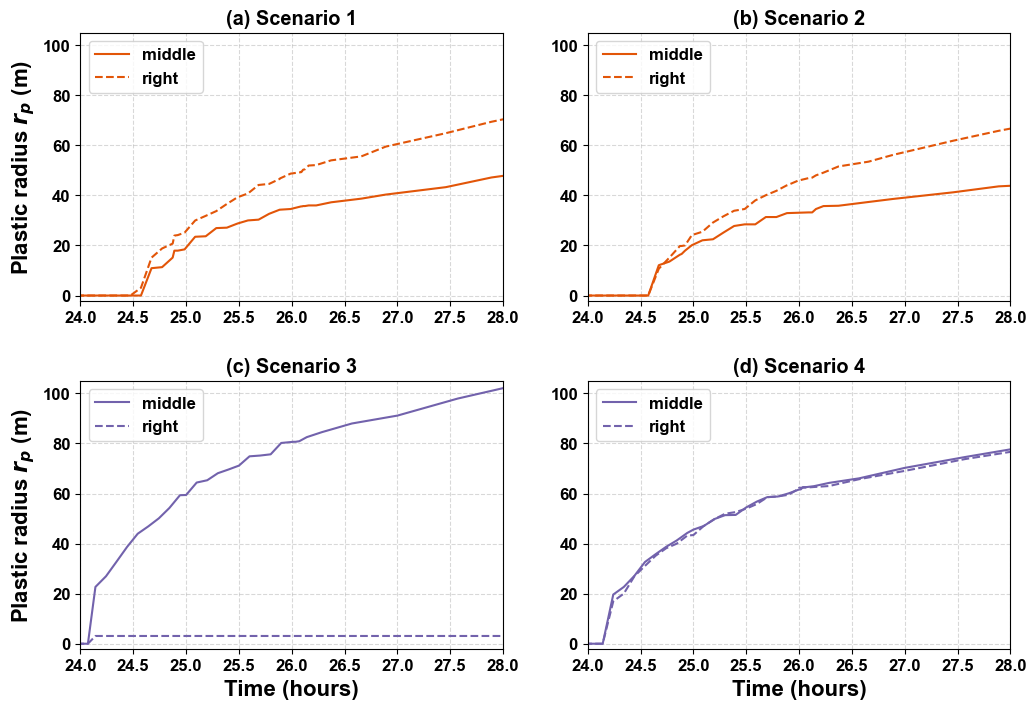

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=False)
axes = axes.ravel()

cases = [
    ("np", "(a) Scenario 1", cm.Oranges(0.7)),
    ("hete_np", "(b) Scenario 2", cm.Oranges(0.7)),
    ("pc", "(c) Scenario 3", cm.Purples(0.7)),
    ("hete", "(d) Scenario 4", cm.Purples(0.7)),
]

for i, (ax, (key, title, color)) in enumerate(zip(axes, cases)):

    t6, ra6 = data6[key]
    t7, ra7 = data7[key]

    ax.plot(t7, np.sqrt(ra7 / np.pi),
        linestyle="-",
        color=color,
        label="middle")

    ax.plot(t6, np.sqrt(ra6 / np.pi),
            linestyle="--",
            color=color,
            label="right")

    ax.set_title(title)
    ax.set_xlim([24, 28])
    ax.set_ylim([-2, 105])

    # --- only first column gets ylabel ---
    if i % 2 == 0:
        ax.set_ylabel('Plastic radius $r_p$ (m)')
    else:
        ax.set_ylabel("")

    # --- only bottom row gets xlabel ---
    if i >= 2:
        ax.set_xlabel("Time (hours)")
    else:
        ax.set_xlabel("")

    ax.grid(True, color="gray", alpha=0.3, linewidth=0.8, linestyle="--")
    ax.legend(loc="upper left")

fig.subplots_adjust(hspace=0.3)

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig4.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.5 Results for no pre-cond

### two cases for middle fault

In [3]:
# read data
# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

base_path_hete_np = (DATA_DIR / '03_heterf_np')
flac_file_hete_np = base_path_hete_np / 'F_clean.parquet'
F_df_hete_np = pd.read_parquet(flac_file_hete_np, engine='pyarrow')

In [4]:
middle_df = F_df_np[F_df_np['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]
print(be4_time)

23
2822.0
2462.0


In [5]:
middle_df = F_df_hete_np[F_df_hete_np['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]
print(be4_time)

23
2822.0
2462.0


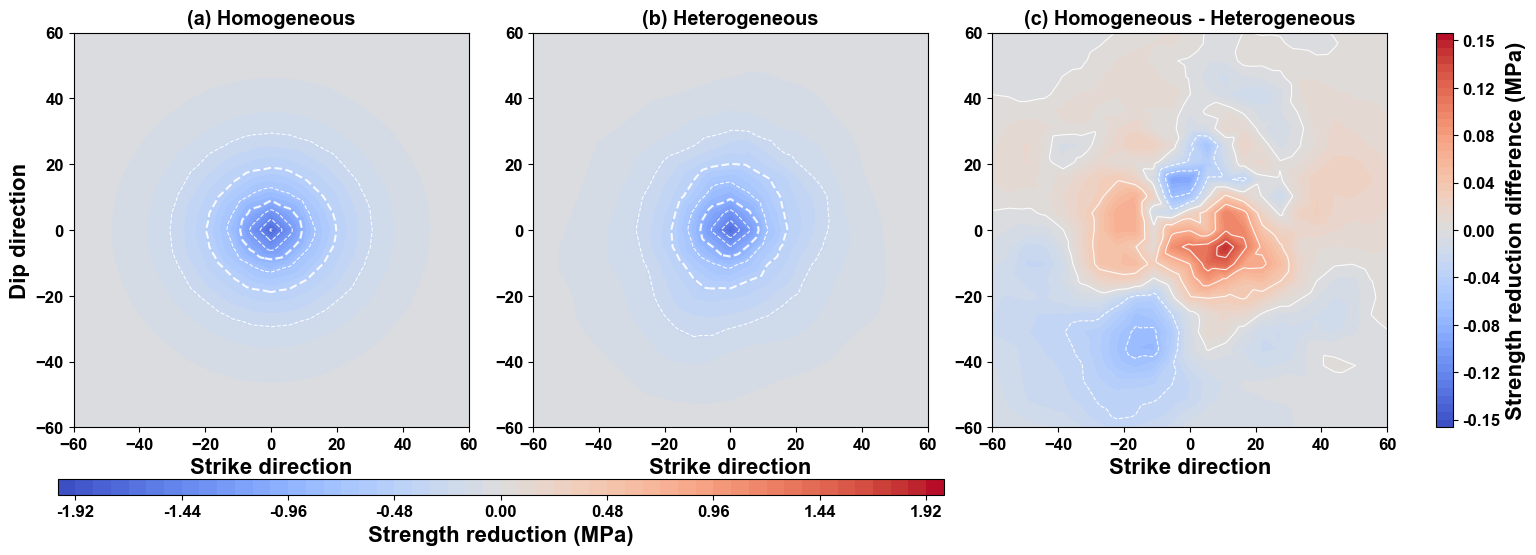

In [6]:
# -----------------------------
# helper
# -----------------------------
def fault_strength(shear, normal, mu_fric=0.21, cohesion=2e6):
    return np.tan(np.deg2rad(21)) * normal + cohesion

def compute_ST_interp(lay, time_val, c_type, n_grid=1000):
    if c_type == "Homogeneous":
        F = F_df_np[F_df_np['ROCK'] == lay]
    else:
        F = F_df_hete_np[F_df_hete_np['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength(sub['Shear_Stress(Pa)'], sub['Normal_Stress(Pa)']) - fault_strength(sub0['Shear_Stress(Pa)'], sub0['Normal_Stress(Pa)'])

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
cases = [
    ("Homogeneous"),
    ("Heterogeneous")
]

plot_data = []
results = {} # store ST fields for later difference

for title in cases:
    y_grid, z_grid, ST = compute_ST_interp(
        lay=7,
        time_val=be4_time,
        c_type = title 
    )

    results[title] = {
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    }

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })

# -----------------------------
# difference case
# -----------------------------
ST_diff = (
    np.abs(results["Homogeneous"]["ST"])
    - np.abs(results["Heterogeneous"]["ST"])
)

plot_data.append({
    "title": "Homogeneous - Heterogeneous",
    "y_grid": results["Homogeneous"]["y_grid"],
    "z_grid": results["Homogeneous"]["z_grid"],
    "ST": ST_diff
})

# -----------------------------
# figure layout: 2 rows × 4 cols
# -----------------------------
fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, 1, 0.04],
    height_ratios=[1, 0.04],
    wspace=0.1,
    hspace=0.25
)

# -----------------------------
# main 3 panels (top row)
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

axes = [ax1, ax2, ax3]

# -----------------------------
# horizontal colorbar axis (bottom row, first 2 panels)
# -----------------------------
cax_h = fig.add_subplot(gs[1, 0:2])

# -----------------------------
# vertical colorbar axis (right column, full height)
# -----------------------------
cax_v = fig.add_subplot(gs[0, 3])

cf_shared = None
cf_diff = None

labels = ["(a)", "(b)", "(c)"]
for i, (ax, item) in enumerate(zip(axes, plot_data)):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]

    Z_plot = Z / 1e6
    # print(np.max(np.abs(Z_plot)))

    # consistent levels
    if title == "Homogeneous - Heterogeneous":
        levels = np.linspace(-0.16, 0.16, 51) # 0.15 for 7
        levels_c = np.linspace(-0.16, 0.16, 11)
        line_widths = 0.8
    else:
        levels = np.linspace(-2, 2, 51)
        
        levels_c = np.linspace(-2, 0, 9)
        line_widths = [0.8] * len(levels_c)
        line_widths[-3] = 1.5  # bold line at -0.5
        line_widths[4] = 1.5  # bold line at -1
        
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z_plot,
        levels=levels,
        cmap="coolwarm"
    )

    # store references
    if title == "Homogeneous - Heterogeneous":
        cf_diff = cf
    else:
        cf_shared = cf

    cs = ax.contour(
        y_grid,
        z_grid,
        Z_plot,
        colors="white",
        levels=levels_c,
        linewidths=line_widths,
        alpha=0.9
    )
    # ax.clabel(cs, inline=True, fontsize=5, fmt="%.2f")

    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")

    ax.set_xlabel("Strike direction")
    if title == "Homogeneous":
        ax.set_ylabel("Dip direction")

# -----------------------------
# horizontal colorbar (first two panels)
# -----------------------------
cbar_h = fig.colorbar(
    cf_shared,
    cax=cax_h,
    orientation="horizontal"
)

cbar_h.set_label("Strength reduction (MPa)")
cbar_h.ax.xaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

# -----------------------------
# vertical colorbar (difference field)
# -----------------------------
cbar_v = fig.colorbar(
    cf_diff,
    cax=cax_v,
    orientation="vertical"
)

cbar_v.set_label("Strength reduction difference (MPa)")
cbar_v.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig5_a.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

### shear stress evolution for heterogeneous case

In [7]:
# read data
# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

In [8]:
middle_df = F_df_np[F_df_np['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]

23
2822.0


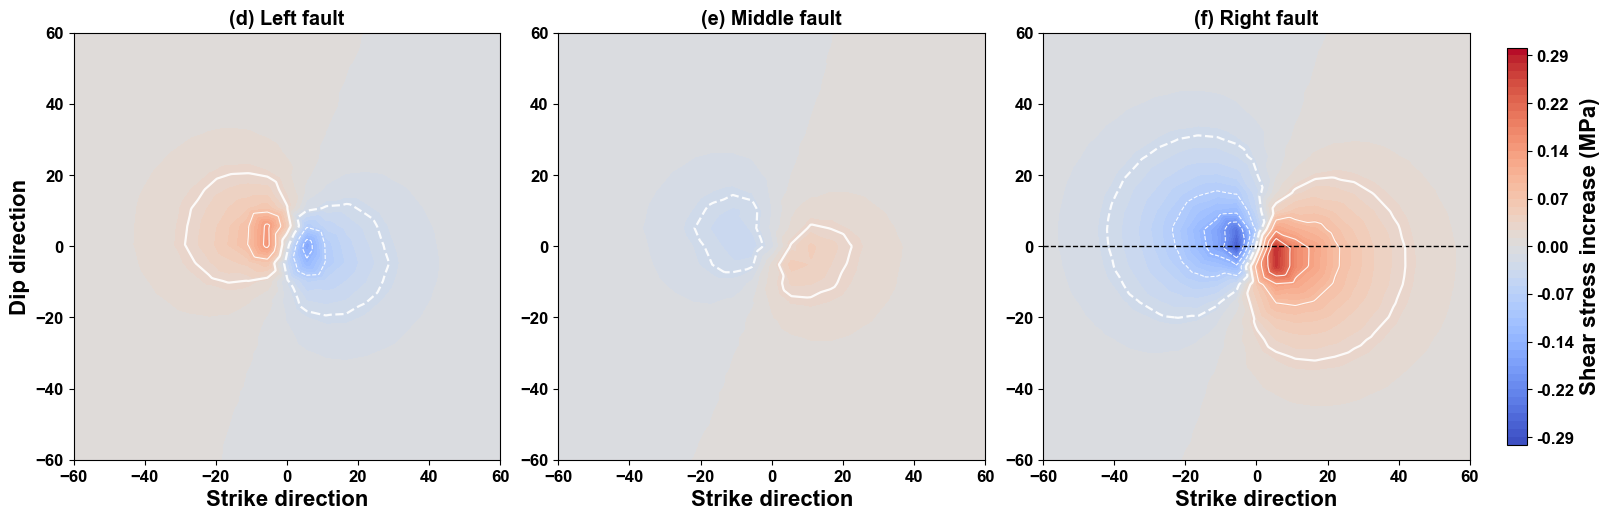

In [9]:
# -----------------------------
# helper
# -----------------------------
def compute_ST_interp(lay, time_val, n_grid=1000):
    F = F_df_np[F_df_np['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = (
        sub['Shear_Stress(Pa)'].to_numpy()
        - sub0['Shear_Stress(Pa)'].to_numpy()
    ) / 1e6
 
    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
faults = [
    (5, "Left fault"),
    (7, "Middle fault"),
    (6, "Right fault"),
]

plot_data = []

for rock_id, title in faults:
    y_grid, z_grid, ST = compute_ST_interp(
        lay=rock_id,
        time_val=be4_time
    )

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })


# -----------------------------
# contour levels
# -----------------------------
levels = np.linspace(-0.2, 0.2, 8) # for make the line bolder
linewidths = [0.8] * len(levels)
linewidths[3] = 1.6
linewidths[4] = 1.6

filled_levels = np.linspace(-0.3, 0.3, 51)

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

labels = ["(d)", "(e)", "(f)"]
for i, (ax, item) in enumerate(zip(axes, plot_data)):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]
    # print(np.max(np.abs(Z)))

    if title == "Left fault":
        ax.set_ylabel("Dip direction")
    if title == "Right fault":
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

    # filled contours using OWN grid
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z,
        levels=filled_levels,
        cmap="coolwarm"
    )

    # contour lines using OWN grid
    cs = ax.contour(
        y_grid,
        z_grid,
        Z,
        levels=levels,
        colors="white",
        linewidths=linewidths,
        alpha=0.9
    )

    # label only bold contours
    label_levels = [levels[3], levels[4]]
    fmt_dict = {
        lv: f"{lv:.2f}"
        for lv in label_levels
    }
    # ax.clabel(cs, levels=label_levels, fmt=fmt_dict, colors='black', fontsize=6, inline=False, inline_spacing=0.1)

    # ax.set_title(title)
    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")


# -----------------------------
# shared colorbar
# -----------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.91, pad=0.02)
cbar.set_label("Shear stress increase (MPa)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig5_b.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

### line profiles

In [10]:
# read data
# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

In [11]:
middle_df = F_df_np[F_df_np['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]

23
2822.0


In [12]:
def fault_strength(normal, mu_fric=0.21, cohesion=2e6):
    return np.tan(np.deg2rad(21)) * normal + cohesion

def get_lineprofile(lay, time_val, z_target):
    F = F_df_np[F_df_np['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)

    y_loc = sub['Y'].to_numpy()
    z_loc = sub['Z'].to_numpy()
    shear =  (sub['Shear_Stress(Pa)'].to_numpy()) / 1e6

    z_target_idx = np.argmin(np.abs(z_loc - z_target)) 
    # find closest index in grid
    z_idx = np.where(z_loc == z_loc[z_target_idx])
    y_line = y_loc[z_idx]
    shear_line = shear[z_idx]

    sort_idx = np.argsort(y_line)
    y_line = y_line[sort_idx]
    shear_line = shear_line[sort_idx]

    return y_line, shear_line

def get_lineprofile_env(lay, time_val, z_target):
    F = F_df_np[F_df_np['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)

    y_loc = sub['Y'].to_numpy()
    z_loc = sub['Z'].to_numpy()
    shear =  (sub['Shear_Stress(Pa)'].to_numpy()) / 1e6
    strength = fault_strength(sub['Normal_Stress(Pa)'].to_numpy()) /1e6

    z_target_idx = np.argmin(np.abs(z_loc - z_target)) 
    # find closest index in grid
    z_idx = np.where(z_loc == z_loc[z_target_idx])
    y_line = y_loc[z_idx]
    shear_line = shear[z_idx]
    strength_line = strength[z_idx]

    sort_idx = np.argsort(y_line)
    y_line = y_line[sort_idx]
    shear_line = shear_line[sort_idx]
    strength_line = strength_line[sort_idx]

    return y_line, shear_line, strength_line

def compute_ST_interp(lay, time_val, n_grid=1000):
    F = F_df_np[F_df_np['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength(sub['Normal_Stress(Pa)'].to_numpy()) /1e6
 
    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid

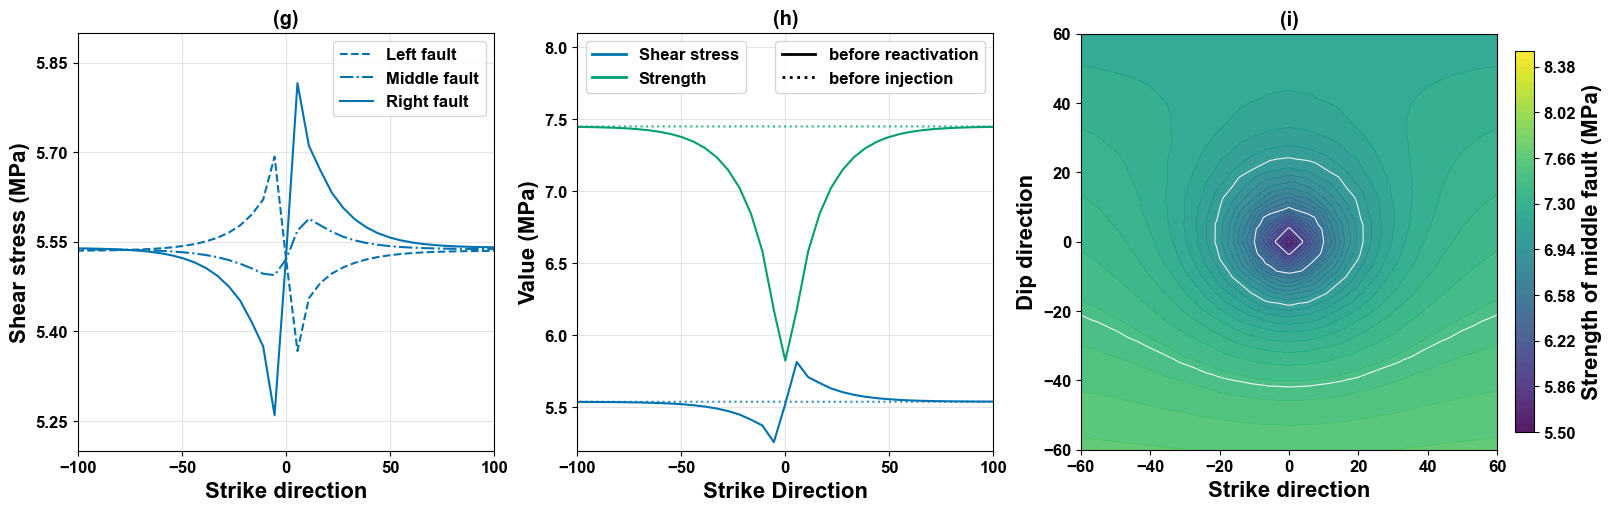

In [13]:
# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

ax = axes[2]
# get the data
y_grid, z_grid, ST = compute_ST_interp(lay=7,time_val=be4_time)

filled_levels = np.linspace(5.5, 8.5 ,51)
cf = ax.contourf(
    y_grid,
    z_grid,
    ST,
    levels=filled_levels,
    cmap="viridis",
    alpha=0.9
)

levels = np.linspace(5.5, 8.5 ,7)
# print(np.max(ST),np.min(ST))
cs = ax.contour(y_grid, z_grid, ST, levels=levels, colors="white", linewidths=0.8, alpha=0.9)
# ax.clabel(cs, levels=levels, colors='black', fontsize=6, inline=False, inline_spacing=0.1)
ax.set_title('(i)')
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_aspect("equal")
ax.set_xlabel("Strike direction")
ax.set_ylabel("Dip direction")

cbar = fig.colorbar(cf, ax=axes[2], shrink=0.91, pad=0.02)
cbar.set_label("Strength of middle fault (MPa)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))


ax = axes[0]
faults = [
    (5, "Left fault"),
    (7, "Middle fault"),
    (6, "Right fault"),
]
styles = ["--", "-.", "-"]
for (rock_id, title), ls in zip(faults, styles):
    y_line, shear_line = get_lineprofile(lay=rock_id, time_val=be4_time, z_target=0)
    ax.plot(y_line, shear_line, "#0072B2", linestyle=ls, label=title)
    # print(np.max(shear_line))
ax.set_xlabel("Strike direction")
ax.set_ylabel("Shear stress (MPa)")
ax.set_xlim([-100, 100])
ax.set_ylim([5.2, 5.9])
ax.set_title("(g)")
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_major_locator(MultipleLocator(0.15))
ax.legend()
ax.grid(True, color='gray', alpha=0.2, linewidth=0.8)


ax = axes[1]
# get the data
y_line0, shear_line0, strength_line0 = get_lineprofile_env(lay=6, time_val=0, z_target=0)
y_line, shear_line, strength_line = get_lineprofile_env(lay=6, time_val=be4_time, z_target=0) # 

# Actual lines (no labels here)
ax.plot(y_line0, shear_line0, color="#0072B2", linestyle=':', alpha=0.8)
ax.plot(y_line0, strength_line0, color="#009E73", linestyle=':', alpha=0.8)

ax.plot(y_line, shear_line, color="#0072B2", linestyle='-')
ax.plot(y_line, strength_line, color="#009E73", linestyle='-')

# Legend 1: color = quantity
legend_colors = [
    Line2D([0], [0], color="#0072B2", lw=2, label="Shear stress"),
    Line2D([0], [0], color="#009E73", lw=2, label="Strength"),
]

# Legend 2: linestyle = fault
legend_styles = [
    Line2D([0], [0], color="black", lw=2, linestyle='-', label="before reactivation"),
    Line2D([0], [0], color="black", lw=2, linestyle=':', label="before injection"),
]

# Add legends
leg1 = ax.legend(handles=legend_colors, loc='upper left')
ax.add_artist(leg1)  # keep first legend

ax.legend(handles=legend_styles, loc='upper right')

ax.set_xlim([-100, 100])
ax.set_ylim([5.2, 8.1])
ax.set_xlabel('Strike Direction')
ax.set_ylabel('Value (MPa)')
ax.set_title('(h)')
ax.grid(True, color='gray', alpha=0.2, linewidth=0.8)
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_major_locator(MultipleLocator(0.5))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig5_c.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()


In [14]:
# for point observation
# print(y_line[45])
# print(shear_line0[45], strength_line0[45])
# print(shear_line[45], strength_line[45])

## Fig.6 Results for with pre-cond

### strength reduction of the middle fault for two cases

In [3]:
# read data
# Load for the no preconditioning case
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

base_path_hete = (DATA_DIR / '03_heterf')
flac_file_hete = base_path_hete / 'F_clean.parquet'
F_df_hete = pd.read_parquet(flac_file_hete, engine='pyarrow')

In [4]:
middle_df = F_df[F_df['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]
print(be4_time)
print(reactivation_time - be4_time)

60
86911.0
86655.0
256.0


In [5]:
middle_df = F_df_hete[F_df_hete['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time_hete = counts.index[reactivation_idx-1]
print(be4_time_hete)
print(reactivation_time - be4_time_hete)

61
87271.0
86911.0
360.0


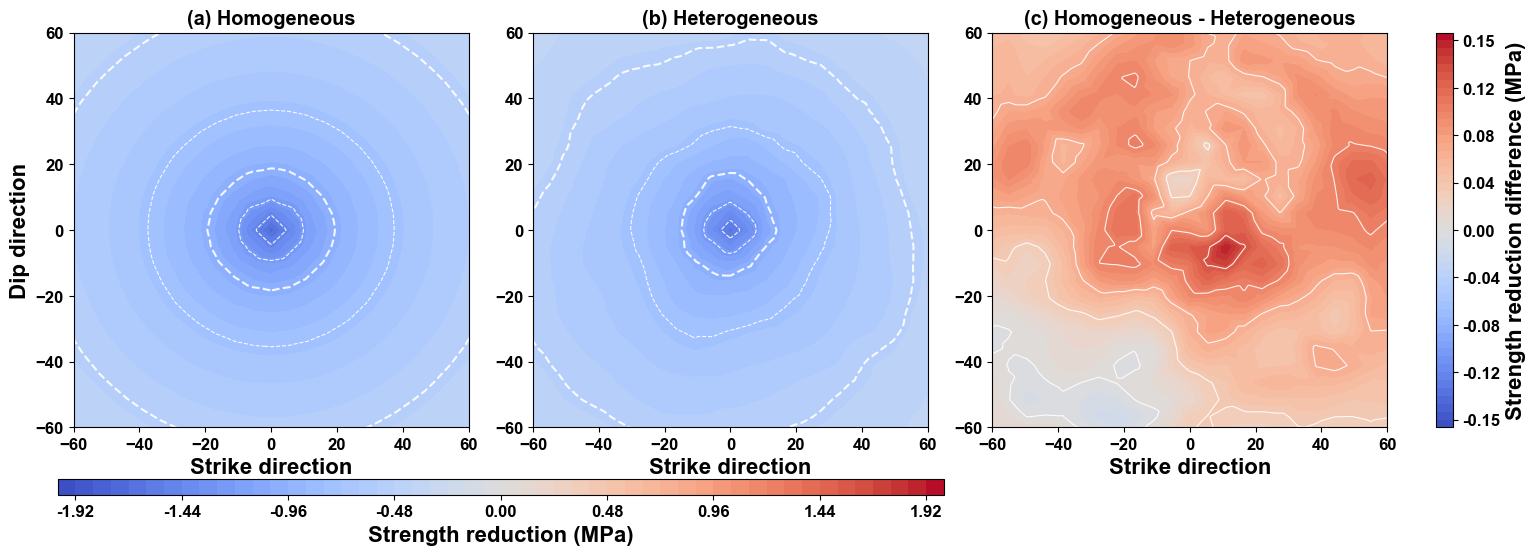

In [6]:
# -----------------------------
# helper
# -----------------------------
def fault_strength(shear, normal, mu_fric=0.21, cohesion=2e6):
    return np.tan(np.deg2rad(21)) * normal + cohesion

def compute_ST_interp(lay, time_val, c_type, n_grid=1000):
    if c_type == "Homogeneous":
        F = F_df[F_df['ROCK'] == lay]
    else:
        F = F_df_hete[F_df_hete['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength(sub['Shear_Stress(Pa)'], sub['Normal_Stress(Pa)']) - fault_strength(sub0['Shear_Stress(Pa)'], sub0['Normal_Stress(Pa)'])

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
cases = [
    ("Homogeneous"),
    ("Heterogeneous")
]

plot_data = []
results = {} # store ST fields for later difference

for title in cases:
    y_grid, z_grid, ST = compute_ST_interp(
        lay=7,
        time_val=be4_time,
        c_type = title 
    )

    results[title] = {
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    }

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })

# -----------------------------
# difference case
# -----------------------------
ST_diff = (
    np.abs(results["Homogeneous"]["ST"])
    - np.abs(results["Heterogeneous"]["ST"])
)

plot_data.append({
    "title": "Homogeneous - Heterogeneous",
    "y_grid": results["Homogeneous"]["y_grid"],
    "z_grid": results["Homogeneous"]["z_grid"],
    "ST": ST_diff
})

# -----------------------------
# figure layout: 2 rows × 4 cols
# -----------------------------
fig = plt.figure(figsize=(18, 6))

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1, 1, 1, 0.04],
    height_ratios=[1, 0.04],
    wspace=0.1,
    hspace=0.25
)

# -----------------------------
# main 3 panels (top row)
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

axes = [ax1, ax2, ax3]

# -----------------------------
# horizontal colorbar axis (bottom row, first 2 panels)
# -----------------------------
cax_h = fig.add_subplot(gs[1, 0:2])

# -----------------------------
# vertical colorbar axis (right column, full height)
# -----------------------------
cax_v = fig.add_subplot(gs[0, 3])

cf_shared = None
cf_diff = None

labels = ["(a)", "(b)", "(c)"]
for i, (ax, item) in enumerate(zip(axes, plot_data)):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]

    Z_plot = Z / 1e6
    # print(np.max(np.abs(Z_plot)))

    # consistent levels
    if title == "Homogeneous - Heterogeneous":
        levels = np.linspace(-0.16, 0.16, 51) # 0.15 for 7
        levels_c = np.linspace(-0.16, 0.16, 11)
        line_widths = 0.8
    else:
        levels = np.linspace(-2, 2, 51)
        
        levels_c = np.linspace(-2, 0, 9)
        line_widths = [0.8] * len(levels_c)
        line_widths[-3] = 1.5  # bold line at -0.5
        line_widths[4] = 1.5  # bold line at -1
        
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z_plot,
        levels=levels,
        cmap="coolwarm"
    )

    # store references
    if title == "Homogeneous - Heterogeneous":
        cf_diff = cf
    else:
        cf_shared = cf

    cs = ax.contour(
        y_grid,
        z_grid,
        Z_plot,
        colors="white",
        levels=levels_c,
        linewidths=line_widths,
        alpha=0.9
    )
    # ax.clabel(cs, inline=True, fontsize=5, fmt="%.2f")

    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")

    ax.set_xlabel("Strike direction")
    if title == "Homogeneous":
        ax.set_ylabel("Dip direction")

# -----------------------------
# horizontal colorbar (first two panels)
# -----------------------------
cbar_h = fig.colorbar(
    cf_shared,
    cax=cax_h,
    orientation="horizontal"
)

cbar_h.set_label("Strength reduction (MPa)")
cbar_h.ax.xaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

# -----------------------------
# vertical colorbar (difference field)
# -----------------------------
cbar_v = fig.colorbar(
    cf_diff,
    cax=cax_v,
    orientation="vertical"
)

cbar_v.set_label("Strength reduction difference (MPa)")
cbar_v.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig6_a.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

### shear stress evolution for homogeneous case

In [7]:
# read data
# Load for the no preconditioning case
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

In [8]:
middle_df = F_df[F_df['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]

60
86911.0


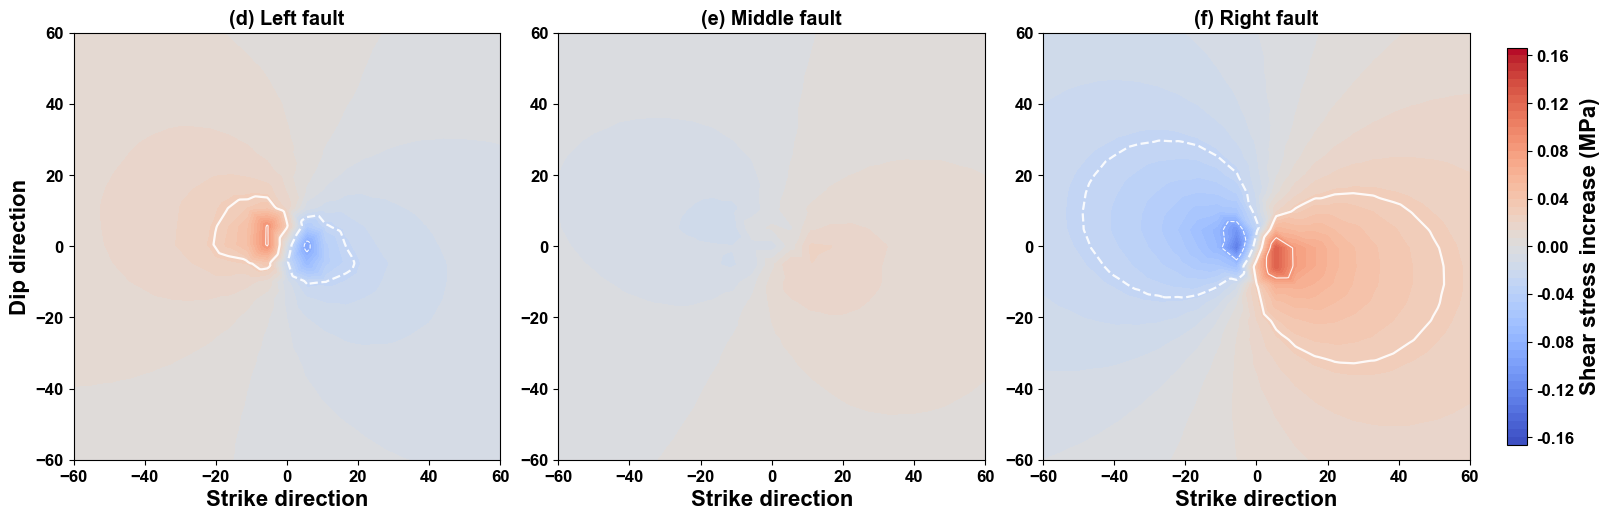

In [9]:
# -----------------------------
# helper
# -----------------------------
def compute_ST_interp(lay, time_val, n_grid=1000):
    F = F_df[F_df['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = (
        sub['Shear_Stress(Pa)'].to_numpy()
        - sub0['Shear_Stress(Pa)'].to_numpy()
    ) / 1e6
 
    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
faults = [
    (5, "Left fault"),
    (7, "Middle fault"),
    (6, "Right fault"),
]

plot_data = []

for rock_id, title in faults:
    y_grid, z_grid, ST = compute_ST_interp(
        lay=rock_id,
        time_val=be4_time
    )

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })


# -----------------------------
# contour levels
# -----------------------------
levels = np.linspace(-0.2, 0.2, 8) # for make the line bolder
linewidths = [0.8] * len(levels)
linewidths[3] = 1.6
linewidths[4] = 1.6

filled_levels = np.linspace(-0.165, 0.165, 51) # for the cases with pre-conditioning

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

labels = ["(d)", "(e)", "(f)"]
# labels = ["(g)", "(h)", "(i)"]
for i, (ax, item) in enumerate(zip(axes, plot_data)):
# for ax, item in zip(axes, plot_data):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]
    # print(np.max(np.abs(Z)))

    if title == "Left fault":
        ax.set_ylabel("Dip direction")

    # filled contours using OWN grid
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z,
        levels=filled_levels,
        cmap="coolwarm"
    )

    # contour lines using OWN grid
    cs = ax.contour(
        y_grid,
        z_grid,
        Z,
        levels=levels,
        colors="white",
        linewidths=linewidths,
        alpha=0.9
    )

    # label only bold contours
    label_levels = [levels[3], levels[4]]
    fmt_dict = {
        lv: f"{lv:.2f}"
        for lv in label_levels
    }
    # ax.clabel(cs, levels=label_levels, fmt=fmt_dict, colors='black', fontsize=6, inline=False, inline_spacing=0.1)

    # ax.set_title(title)
    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")


# -----------------------------
# shared colorbar
# -----------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.91, pad=0.02)
cbar.set_label("Shear stress increase (MPa)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig6_b.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

### shear stress evolution for heterogeneous case

In [10]:
# read data
# Load for the no preconditioning case
base_path = (DATA_DIR / '03_heterf')
flac_file = base_path / 'F_clean.parquet'
F_df_hete = pd.read_parquet(flac_file, engine='pyarrow')

In [11]:
be4_time = 86655.0 # the time defined by the homogeneous case, since it's reactivated earlier

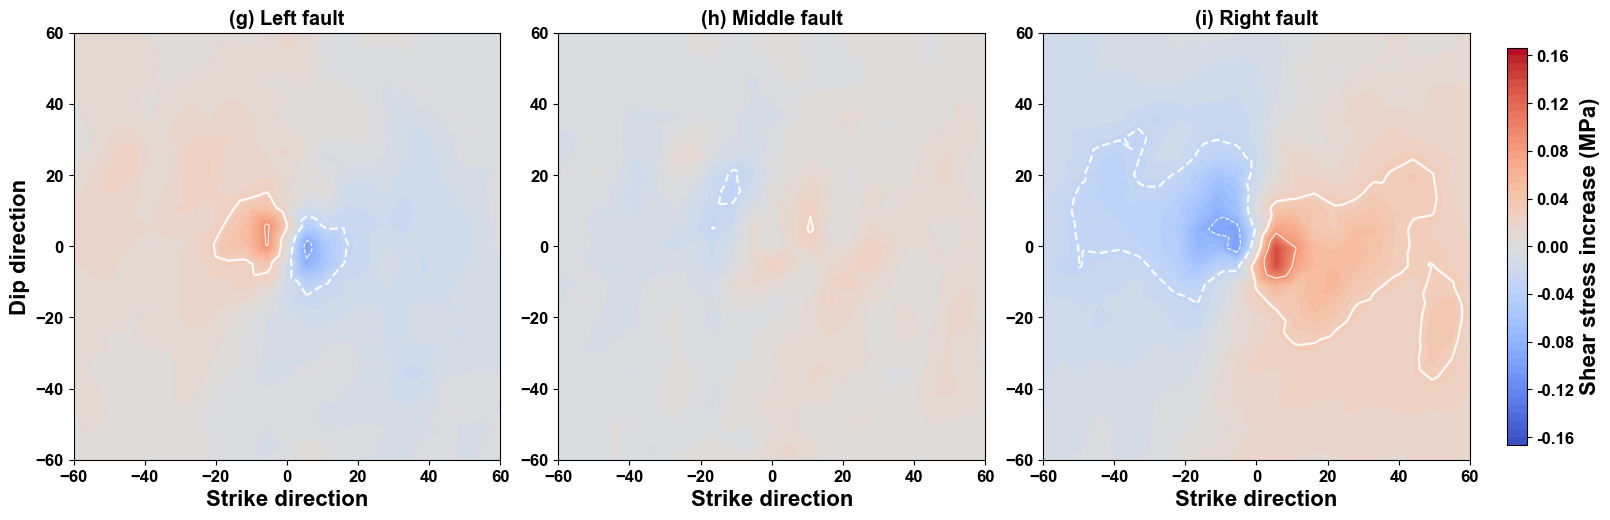

In [12]:
# -----------------------------
# helper
# -----------------------------
def compute_ST_interp(lay, time_val, n_grid=1000):
    F = F_df_hete[F_df_hete['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = (
        sub['Shear_Stress(Pa)'].to_numpy()
        - sub0['Shear_Stress(Pa)'].to_numpy()
    ) / 1e6
 
    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
faults = [
    (5, "Left fault"),
    (7, "Middle fault"),
    (6, "Right fault"),
]

plot_data = []

for rock_id, title in faults:
    y_grid, z_grid, ST = compute_ST_interp(
        lay=rock_id,
        time_val=be4_time
    )

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })


# -----------------------------
# contour levels
# -----------------------------
levels = np.linspace(-0.2, 0.2, 8) # for make the line bolder
linewidths = [0.8] * len(levels)
linewidths[3] = 1.6
linewidths[4] = 1.6

filled_levels = np.linspace(-0.165, 0.165, 51) # for the cases with pre-conditioning

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

labels = ["(g)", "(h)", "(i)"]
for i, (ax, item) in enumerate(zip(axes, plot_data)):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]

    if title == "Left fault":
        ax.set_ylabel("Dip direction")

    # filled contours using OWN grid
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z,
        levels=filled_levels,
        cmap="coolwarm"
    )

    # contour lines using OWN grid
    cs = ax.contour(
        y_grid,
        z_grid,
        Z,
        levels=levels,
        colors="white",
        linewidths=linewidths,
        alpha=0.9
    )

    # label only bold contours
    label_levels = [levels[3], levels[4]]
    fmt_dict = {
        lv: f"{lv:.2f}"
        for lv in label_levels
    }
    # ax.clabel(cs, levels=label_levels, fmt=fmt_dict, colors='black', fontsize=6, inline=False, inline_spacing=0.1)

    # ax.set_title(title)
    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")


# -----------------------------
# shared colorbar
# -----------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.91, pad=0.02)
cbar.set_label("Shear stress increase (MPa)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig6_c.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.7 Reactivation comparison

In [3]:
def get_reactivation_time(fault_layer, strain_col="Strain_P", threshold=2):
    counts = (fault_layer[strain_col] > 0).groupby(fault_layer["Time"]).sum()
    arr = counts.values

    mask = arr > threshold
    if mask.any():
        idx = np.argmax(mask)
        return idx, counts.index[idx], counts
    else:
        return None, None, counts

In [4]:
# read data
# Load for the no preconditioning case
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')
F_intem = F_df[F_df['ROCK']==7]

base_path_hete = (DATA_DIR / '03_heterf')
flac_file_hete = base_path_hete / 'F_clean.parquet'
F_df_hete = pd.read_parquet(flac_file_hete, engine='pyarrow')
F_intem_hete = F_df_hete[F_df_hete['ROCK']==7]

In [5]:
idx_ho, t_ho, counts_ho = get_reactivation_time(F_intem)
idx_he, t_he, counts_he = get_reactivation_time(F_intem_hete)

print(t_ho)
print(t_he)

86911.0
87271.0


In [6]:
# choose the earlier (smaller) valid time
shared_st = counts_ho.index[idx_ho-1]
shared_et = counts_he.index[idx_he+5]

In [7]:
# choose z location for the profile
z_target = 0

#### process the first case
subset = F_intem[F_intem['Time'] == shared_et].reset_index(drop=True)
mask_plot = subset['Strain_P']>0

# find the area
z_loc = subset['Z'].to_numpy()
y_loc = subset['Y'].to_numpy()

mu_shear = subset['Shear_Stress(Pa)'].values / 1e6
mu_st = (np.tan(np.deg2rad(21)) * subset['Normal_Stress(Pa)'].values + 2e6) /1e6
mu_st[mask_plot] = subset['Shear_Stress(Pa)'].values[mask_plot] / 1e6 

z_target_idx = np.argmin(np.abs(z_loc - z_target)) 
# find closest index in grid
z_idx = np.where(z_loc == z_loc[z_target_idx])

y_line = y_loc[z_idx]
mu_shear_line = mu_shear[z_idx]
mu_st_line = mu_st[z_idx]

sort_idx = np.argsort(y_line)
y_line = y_line[sort_idx]
mu_shear_line = mu_shear_line[sort_idx]
mu_st_line = mu_st_line[sort_idx]

#### process the second case
subset_np = F_intem[F_intem['Time'] == shared_st].reset_index(drop=True)
mask_plot_np = subset_np['Strain_P']>0

# find the area
z_loc_np = subset_np['Z'].to_numpy()
y_loc_np = subset_np['Y'].to_numpy()

mu_shear_np = subset_np['Shear_Stress(Pa)'].values / 1e6
mu_st_np = (np.tan(np.deg2rad(21)) * subset_np['Normal_Stress(Pa)'].values + 2e6) /1e6
mu_st_np[mask_plot_np] = subset_np['Shear_Stress(Pa)'].values[mask_plot_np] / 1e6 

z_target_idx = np.argmin(np.abs(z_loc_np - z_target)) 
# find closest index in grid
z_idx_np = np.where(z_loc_np == z_loc_np[z_target_idx])

y_line_np = y_loc_np[z_idx_np]
mu_shear_line_np = mu_shear_np[z_idx_np]
mu_st_line_np = mu_st_np[z_idx_np]

sort_idx = np.argsort(y_line_np)
y_line_np = y_line_np[sort_idx]
mu_shear_line_np = mu_shear_line_np[sort_idx]
mu_st_line_np = mu_st_line_np[sort_idx]


In [8]:
results = {}

results['homog'] = {
    "y_line": y_line,
    "mu_shear_line": mu_shear_line,
    "mu_st_line": mu_st_line,
    "y_line_np": y_line_np,
    "mu_shear_line_np": mu_shear_line_np,
    "mu_st_line_np": mu_st_line_np,
}

In [9]:
# choose z location for the profile
z_target = 0

#### process the first case
subset = F_df_hete[F_df_hete['Time'] == shared_et].reset_index(drop=True)
mask_plot = subset['Strain_P']>0

# find the area
z_loc = subset['Z'].to_numpy()
y_loc = subset['Y'].to_numpy()

mu_shear = subset['Shear_Stress(Pa)'].values / 1e6
mu_st = (np.tan(np.deg2rad(21)) * subset['Normal_Stress(Pa)'].values + 2e6) /1e6
mu_st[mask_plot] = subset['Shear_Stress(Pa)'].values[mask_plot] / 1e6 

z_target_idx = np.argmin(np.abs(z_loc - z_target)) 
# find closest index in grid
z_idx = np.where(z_loc == z_loc[z_target_idx])

y_line = y_loc[z_idx]
mu_shear_line = mu_shear[z_idx]
mu_st_line = mu_st[z_idx]

sort_idx = np.argsort(y_line)
y_line = y_line[sort_idx]
mu_shear_line = mu_shear_line[sort_idx]
mu_st_line = mu_st_line[sort_idx]

#### process the second case
subset_np = F_df_hete[F_df_hete['Time'] == shared_st].reset_index(drop=True)
mask_plot_np = subset_np['Strain_P']>0

# find the area
z_loc_np = subset_np['Z'].to_numpy()
y_loc_np = subset_np['Y'].to_numpy()

mu_shear_np = subset_np['Shear_Stress(Pa)'].values / 1e6
mu_st_np = (np.tan(np.deg2rad(21)) * subset_np['Normal_Stress(Pa)'].values + 2e6) /1e6
mu_st_np[mask_plot_np] = subset_np['Shear_Stress(Pa)'].values[mask_plot_np] / 1e6 

z_target_idx = np.argmin(np.abs(z_loc_np - z_target)) 
# find closest index in grid
z_idx_np = np.where(z_loc_np == z_loc_np[z_target_idx])

y_line_np = y_loc_np[z_idx_np]
mu_shear_line_np = mu_shear_np[z_idx_np]
mu_st_line_np = mu_st_np[z_idx_np]

sort_idx = np.argsort(y_line_np)
y_line_np = y_line_np[sort_idx]
mu_shear_line_np = mu_shear_line_np[sort_idx]
mu_st_line_np = mu_st_line_np[sort_idx]

In [10]:
results['heter'] = {
    "y_line": y_line,
    "mu_shear_line": mu_shear_line,
    "mu_st_line": mu_st_line,
    "y_line_np": y_line_np,
    "mu_shear_line_np": mu_shear_line_np,
    "mu_st_line_np": mu_st_line_np,
}

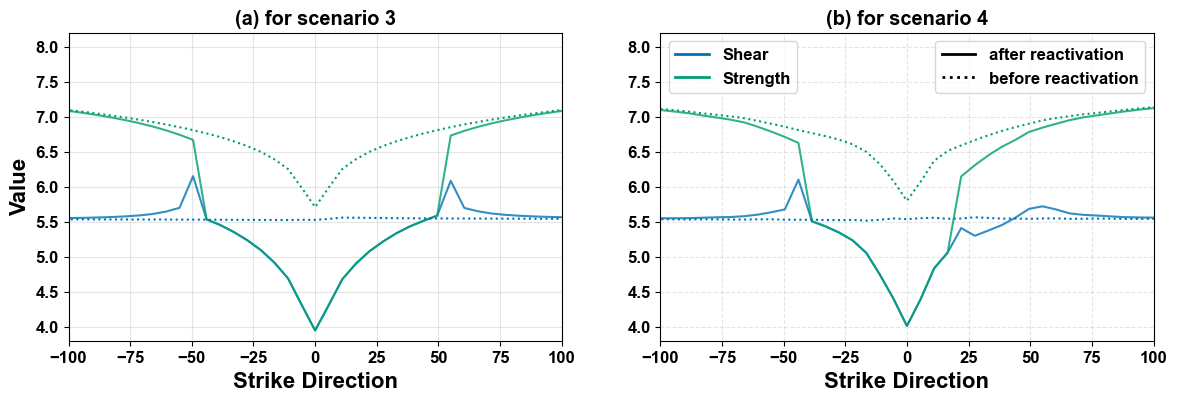

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=False)

ax = axes[0]
r = results['homog']

# lines
ax.plot(r['y_line'], r['mu_shear_line'], color="#0072B2", linestyle='-', alpha=0.8)
ax.plot(r['y_line'], r['mu_st_line'],    color="#009E73", linestyle='-', alpha=0.8)

ax.plot(r['y_line_np'], r['mu_shear_line_np'], color="#0072B2", linestyle=':')
ax.plot(r['y_line_np'], r['mu_st_line_np'],    color="#009E73", linestyle=':')

# axes formatting (on ax, not plt)
ax.set_xlim([-100, 100])
ax.set_ylim([3.8, 8.2])
ax.set_xlabel('Strike Direction')
ax.set_title('(a) for scenario 3')
ax.set_ylabel('Value')
ax.grid(True, color='gray', alpha=0.2, linewidth=0.8)

ax = axes[1]
r = results['heter']

# lines
ax.plot(r['y_line'], r['mu_shear_line'], color="#0072B2", linestyle='-', alpha=0.8)
ax.plot(r['y_line'], r['mu_st_line'],    color="#009E73", linestyle='-', alpha=0.8)

ax.plot(r['y_line_np'], r['mu_shear_line_np'], color="#0072B2", linestyle=':')
ax.plot(r['y_line_np'], r['mu_st_line_np'],    color="#009E73", linestyle=':')

# legend 1: quantity (color)
legend_colors = [
    Line2D([0], [0], color="#0072B2", lw=2, label="Shear"),
    Line2D([0], [0], color="#009E73", lw=2, label="Strength"),
]

leg1 = ax.legend(handles=legend_colors, loc='upper left')
ax.add_artist(leg1)

# legend 2: linestyle (state)
legend_styles = [
    Line2D([0], [0], color="black", lw=2, linestyle='-', label="after reactivation"),
    Line2D([0], [0], color="black", lw=2, linestyle=':', label="before reactivation"),
]

ax.legend(handles=legend_styles, loc='upper right')

# axes formatting (on ax, not plt)
ax.set_xlim([-100, 100])
ax.set_ylim([3.8, 8.2])
ax.set_title('(b) for scenario 4')
ax.set_xlabel('Strike Direction')
ax.grid(True, color='gray', alpha=0.2, linewidth=0.8, linestyle='--')

fig.subplots_adjust(wspace=0.2)

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig7.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.8 comparison between homogeneous case and heterogeneous case

In [3]:
# read data
# File paths
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

# Load for the no preconditioning case
base_path_np = (DATA_DIR / '02_homogf_np')
flac_file_np = base_path_np / 'F_clean.parquet'
F_df_np = pd.read_parquet(flac_file_np, engine='pyarrow')

base_path_hete = (DATA_DIR / '03_heterf')
flac_file_hete = base_path_hete / 'F_clean.parquet'
F_df_hete = pd.read_parquet(flac_file_hete, engine='pyarrow')

base_path_hete_np = (DATA_DIR / '03_heterf_np')
flac_file_hete_np = base_path_hete_np / 'F_clean.parquet'
F_df_hete_np = pd.read_parquet(flac_file_hete_np, engine='pyarrow')

# Load for the case where biot = 1e-3
base_path_b0 = (DATA_DIR / '04_homogf_biot0_hf')
flac_file_b0 = base_path_b0 / 'F_clean.parquet'
F_df_b0 = pd.read_parquet(flac_file_b0, engine='pyarrow')

In [4]:
fault_map = {7: '(middle / injection)', 6: '(right)', 5: '(left)'} 
cell_map = {7: 'ASX79', 6: 'AU588',  5: 'ARQ70'}

lay_num = 6
cell = cell_map.get(lay_num)

F_intem = F_df[F_df['ROCK']==lay_num]
F_np_intem = F_df_np[F_df_np['ROCK']==lay_num]
F_hete_intem = F_df_hete[F_df_hete['ROCK']==lay_num]
F_hete_np_intem = F_df_hete_np[F_df_hete_np['ROCK']==lay_num]
F_b0_intem = F_df_b0[F_df_b0['ROCK']==lay_num]

inj_point_F = F_intem[F_intem['ELEM'] == cell]  
inj_point_F_np = F_np_intem[F_np_intem['ELEM'] == cell]  
inj_point_F_hete_np = F_hete_np_intem[F_hete_np_intem['ELEM'] == cell]  
inj_point_F_b0 = F_b0_intem[F_b0_intem['ELEM'] == cell]  
inj_point_F_hete = F_hete_intem[F_hete_intem['ELEM'] == cell]  

In [5]:
inj_point_F_b0 = inj_point_F_b0[inj_point_F_b0['Time'] < 28 * 3600]

In [6]:
def insert_reactivation_row(
    F_df,
    inj_point_F_np,
    lay_num,
    strain_col='Strain_P',
    rock_col='ROCK',
    time_col='Time',
    normal_stress_col='Normal_Stress(Pa)',
    shear_stress_col='Shear_Stress(Pa)',
    friction_angle_deg=21,
    cohesion=2e6,
    threshold=2
):
    """
    Find the first reactivation time and insert a new row with
    modified shear stress before the matching row in inj_point_F_np.

    Returns
    -------
    inj_point_F_np_new : pd.DataFrame
        Updated dataframe with inserted row.
    reactivation_time : scalar or None
    reactivation_value : int
    reactivation_idx : int or None
    """

    # Filter by layer
    middle_df = F_df[F_df[rock_col] == lay_num]

    # Count positive strain values per time
    counts = (middle_df[strain_col] > 0).groupby(middle_df[time_col]).sum()

    arr = counts.values
    nonzero_mask = arr > threshold

    if nonzero_mask.any():
        reactivation_idx = np.argmax(nonzero_mask)
        reactivation_time = counts.index[reactivation_idx]
        reactivation_value = arr[reactivation_idx]
    else:
        print("No reactivation found.")
        return inj_point_F_np, None, 0, None

    print(f"Reactivation index: {reactivation_idx}")
    print(f"Reactivation time: {reactivation_time}")

    # Optional: previous time
    be4_time = counts.index[reactivation_idx - 1] if reactivation_idx > 0 else None

    # Find matching row in inj_point_F_np
    matches = np.where(
        inj_point_F_np[time_col].to_numpy() == reactivation_time
    )[0]

    if len(matches) == 0:
        print("No matching Time value found.")
        return inj_point_F_np, reactivation_time, reactivation_value, reactivation_idx

    idx = matches[0]

    if idx == 0:
        raise ValueError("Cannot copy Shear from previous row (idx = 0).")

    # Create new row
    new_row = inj_point_F_np.iloc[idx].copy()
    new_row[shear_stress_col] = (
        np.tan(np.deg2rad(friction_angle_deg))
        * new_row[normal_stress_col]
        + cohesion
    )

    # Insert row
    inj_point_F_np_new = pd.concat(
        [
            inj_point_F_np.iloc[:idx],
            pd.DataFrame([new_row]),
            inj_point_F_np.iloc[idx:]
        ],
        ignore_index=True
    )

    return (
        inj_point_F_np_new,
        reactivation_time,
        reactivation_value,
        reactivation_idx,
    )

In [7]:
inj_point_F_hete_plot, _, _, _ = (insert_reactivation_row(F_df_hete, inj_point_F_hete,6))
inj_point_F_hete_np_plot, _, _, _ = (insert_reactivation_row(F_df_hete_np, inj_point_F_hete_np,6))
inj_point_F_plot, _, _, _ = (insert_reactivation_row(F_df, inj_point_F,6))
# _, _, _, _ = (insert_reactivation_row(F_df_np, inj_point_F_np,6))
inj_point_F_b0_plot, _, _, _ = (insert_reactivation_row(F_df_b0, inj_point_F_b0,6,friction_angle_deg=24,cohesion=2e6))

Reactivation index: 61
Reactivation time: 87271.0
Reactivation index: 23
Reactivation time: 2822.0
No reactivation found.
Reactivation index: 61
Reactivation time: 87271.0


In [8]:
# Keep the original first row
first_row = inj_point_F_hete_np_plot.iloc[[0]]
# Keep rows with Time >= 400
filtered = inj_point_F_hete_np_plot[inj_point_F_hete_np_plot['Time'] >= 400].copy()
filtered['Time'] -= (400 - 24 * 3600)
# Combine them
inj_point_F_hete_np_plot = pd.concat([first_row, filtered], ignore_index=True)

In [9]:
def extract(df):
    x = df['Normal_Stress(Pa)'].to_numpy() / 1e6
    y = df['Shear_Stress(Pa)'].to_numpy() / 1e6
    t = df['Time'].to_numpy() / 3600
    return x, y, t


def truncate_colormap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )


def plot_path(x, y, t, cmap, label, ls='-', alpha=0.85):
    sc = ax.scatter(
        x, y,
        c=t,
        cmap=cmap,
        norm=norm,
        s=45,
        edgecolor='none',
        alpha=alpha,
        label=label,
        zorder=3
    )
    ax.plot(x, y, color='k', lw=0.8, alpha=0.2, linestyle=ls, zorder=2)

    target_time = 24 * 3600
    idx = np.where(np.isclose(t, 24))[0]

    if len(idx) > 0:
        ax.scatter(
            x[idx],
            y[idx],
            marker='x',
            s=50,
            linewidths=2,
            color='yellow',
            zorder=10
        )

    return sc



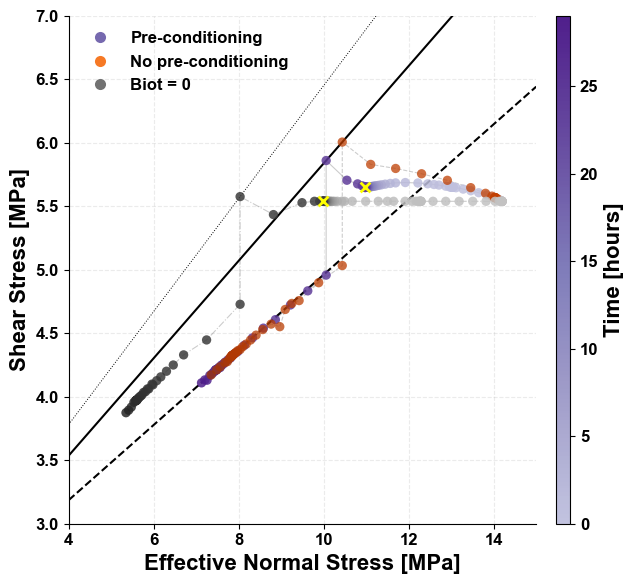

In [10]:

# --- Keep your original aesthetic family ---
cmap_nopre   = truncate_colormap(cm.Oranges, 0.35, 0.9)
cmap_pre = truncate_colormap(cm.Purples, 0.35, 0.9)
cmap_biot  = truncate_colormap(cm.Greys, 0.35, 0.9)


x1, y1, t1 = extract(inj_point_F_hete_plot)
x2, y2, t2 = extract(inj_point_F_hete_np_plot)
x3, y3, t3 = extract(inj_point_F_b0_plot)

# shared normalization (important for comparability)
t_all = np.concatenate([t1, t2, t3])
norm = plt.Normalize(t_all.min(), t_all.max())


fig, ax = plt.subplots(figsize=(6.5, 6))

# --- Paths ---
sc1 = plot_path(x1, y1, t1, cmap_pre,   "Pre-conditioning", '-')
sc2 = plot_path(x2, y2, t2, cmap_nopre, "No pre-conditioning", '--', alpha=0.75)
sc3 = plot_path(x3, y3, t3, cmap_biot,  "Biot = 0", '-.')


# --- Friction lines (clean + interpretable) ---
x_vals = np.linspace(4, 15, 200)

# lower friction bound (solid black)
mu1 = np.tan(np.deg2rad(16.5))
ax.plot(
    x_vals, mu1 * x_vals + 2,
    color='black', linestyle='--',
    # label='Friction 16.5°'
)

# upper friction bound (dashed black)
mu2 = np.tan(np.deg2rad(21))
ax.plot(
    x_vals, mu2 * x_vals + 2,
    color='black', linestyle='-',
    # label='Friction 21°'
)

mu1 = np.tan(np.deg2rad(24))
ax.plot(
    x_vals, mu1 * x_vals + 2,
    color='black', linestyle=':',linewidth=0.7,
    # label='Friction 16.5°'
)

# --- Styling ---
ax.set_xlabel('Effective Normal Stress [MPa]')
ax.set_ylabel('Shear Stress [MPa]')
ax.set_xlim(4, 15)
ax.set_ylim(3, 7)
# ax.set_ylim(5.5, 6)

ax.grid(True, alpha=0.25, linestyle='--')
# ax.grid(True, color='gray', alpha=0.2, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# --- Single clean colorbar ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_pre)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Time [hours]')


# ax.legend(frameon=False, loc='upper left')

legend_handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_pre(0.6),
           markeredgecolor='none',
           markersize=8,
           label='Pre-conditioning'),

    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_nopre(0.4),
           markeredgecolor='none',
           markersize=8,
           label='No pre-conditioning'),

    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_biot(0.5),
           markeredgecolor='none',
           markersize=8,
           label='Biot = 0')
]

ax.legend(handles=legend_handles, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

86655.0
86655.0
86911.0


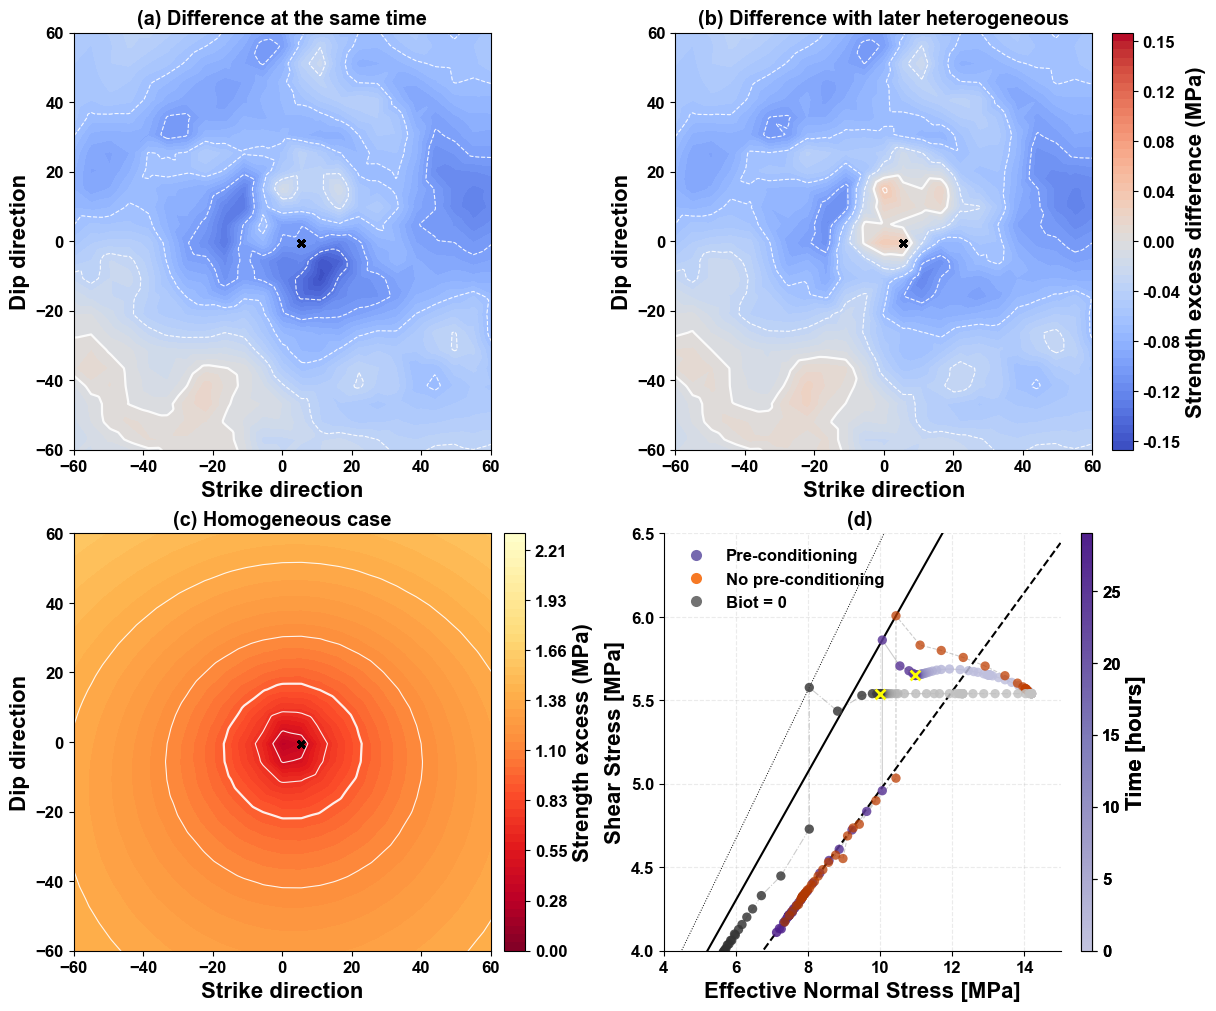

In [11]:
# -----------------------------
# helper
# -----------------------------
def fault_strength_stress_diff(shear, normal, mu_fric=0.21, cohesion=2e6):
    return (np.tan(np.deg2rad(21)) * normal + cohesion) - shear

def get_reactivation_time(df, lay_num, strain_col="Strain_P", threshold=0):
    fault_layer = df[df['ROCK']==lay_num]
    counts = (fault_layer[strain_col] > 0).groupby(fault_layer["Time"]).sum()
    arr = counts.values

    mask = arr > threshold
    if mask.any():
        idx = np.argmax(mask)
        return idx, counts.index[idx], counts
    else:
        return None, None, counts
        
def compute_ST_interp(lay, time_val, c_type, n_grid=1000):
    if c_type == "Homogeneous":
        F = F_df[F_df['ROCK'] == lay]
    else:
        F = F_df_hete[F_df_hete['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength_stress_diff(sub['Shear_Stress(Pa)'], sub['Normal_Stress(Pa)'])

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid

# -----------------------------
# prepare datasets
# -----------------------------
cases = [
    ("Homogeneous"),
    ("Heterogeneous1"),
    ("Heterogeneous2")
]

plot_data = []
results = {} # store ST fields for later difference

for title in cases:
    if title == "Heterogeneous2":
        re_idx, re_t, counts = get_reactivation_time(F_df_hete, 7)
        print(counts.index[re_idx-1]) 
    else: 
        re_idx, re_t, counts = get_reactivation_time(F_df, 7)
        print(counts.index[re_idx-1])

    y_grid, z_grid, ST = compute_ST_interp(
        lay=6,
        time_val = counts.index[re_idx-1],
        c_type = title 
    )

    results[title] = {
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    }
    if title == "Homogeneous": 
        plot_data.append({
            "title": title,
            "y_grid": y_grid,
            "z_grid": z_grid,
            "ST": ST
        })

# -----------------------------
# difference case
# -----------------------------
ST_diff1 = (
    results["Homogeneous"]["ST"]
    - results["Heterogeneous1"]["ST"]
)

ST_diff2 = (
    results["Homogeneous"]["ST"]
    - results["Heterogeneous2"]["ST"]
)

plot_data.append({
    "title": "Same time",
    "y_grid": results["Homogeneous"]["y_grid"],
    "z_grid": results["Homogeneous"]["z_grid"],
    "ST": ST_diff1
})

plot_data.append({
    "title": "later",
    "y_grid": results["Homogeneous"]["y_grid"],
    "z_grid": results["Homogeneous"]["z_grid"],
    "ST": ST_diff2
})

plot_data.append(plot_data.pop(0))

# -----------------------------
# plot
# -----------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    constrained_layout=True
)

axes = axes.ravel()  # flatten to 1D for easy looping

cf_shared = None
cf_diff = None

for ax, item in zip(axes[:3], plot_data):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]

    # different levels for difference plot
    if title == "Homogeneous":
        levels = np.linspace(0, 2.3, 51)
        levels_c = np.linspace(0, 2.3, 11)
        leves_les = [0.8] * len(levels_c)
        leves_les[4] = 1.6
        c_map_use = 'YlOrRd_r'
    else:
        levels = np.linspace(-0.16, 0.16, 51)  # choose suitable range
        levels_c = np.linspace(-0.16, 0.16, 11)
        c_map_use = "coolwarm"
        leves_les = [0.8] * len(levels_c)
        leves_les[5] = 1.6

    # contourf
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z / 1e6,
        levels=levels,
        cmap=c_map_use
    )

    # store handles
    if title == "Homogeneous":
        cf_diff = cf
    else:
        cf_shared = cf

    # contour lines
    cs = ax.contour(
        y_grid,
        z_grid,
        Z / 1e6,
        colors="white",
        linewidths=leves_les,
        alpha=0.9,
        levels=levels_c
    )
    # ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")

    ax.scatter(inj_point_F['Y'], inj_point_F['Z'], color='k', s=25, marker='x')
    
    ax.set_title(title)
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")
    ax.set_ylabel("Dip direction")

ax = axes[3]
# --- Paths ---
sc1 = plot_path(x1, y1, t1, cmap_pre,   "Pre-conditioning", '-')
sc2 = plot_path(x2, y2, t2, cmap_nopre, "No pre-conditioning", '--', alpha=0.75)
sc3 = plot_path(x3, y3, t3, cmap_biot,  "Biot = 0", '-.')

# --- Friction lines (clean + interpretable) ---
x_vals = np.linspace(4, 15, 200)

# lower friction bound (solid black)
mu1 = np.tan(np.deg2rad(16.5))
ax.plot(
    x_vals, mu1 * x_vals + 2,
    color='black', linestyle='--',
    # label='Friction 16.5°'
)

# upper friction bound (dashed black)
mu2 = np.tan(np.deg2rad(21))
ax.plot(
    x_vals, mu2 * x_vals + 2,
    color='black', linestyle='-',
    # label='Friction 21°'
)

mu1 = np.tan(np.deg2rad(24))
ax.plot(
    x_vals, mu1 * x_vals + 2,
    color='black', linestyle=':',linewidth=0.7,
)

# --- Styling ---
ax.set_xlabel('Effective Normal Stress [MPa]')
ax.set_ylabel('Shear Stress [MPa]')
ax.set_xlim(4, 15)
ax.set_ylim(3, 7)


ax.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# --- Single clean colorbar ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_pre)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Time [hours]')

# --- Styling ---
ax.set_xlabel('Effective Normal Stress [MPa]')
ax.set_ylabel('Shear Stress [MPa]')
ax.set_xlim(4, 15)
ax.set_ylim(4, 6.5)

legend_handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_pre(0.6),
           markeredgecolor='none',
           markersize=8,
           label='Pre-conditioning'),

    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_nopre(0.4),
           markeredgecolor='none',
           markersize=8,
           label='No pre-conditioning'),

    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=cmap_biot(0.5),
           markeredgecolor='none',
           markersize=8,
           label='Biot = 0')
]

ax.legend(handles=legend_handles, frameon=False, loc='upper left')


ax.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# --- Single clean colorbar ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_pre)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Time [hours]')


# -----------------------------
# shared colorbar for first 2
# -----------------------------
cbar1 = fig.colorbar(
    cf_shared,
    ax=axes[:2],
    # shrink=0.95,
    pad=0.01
)
cbar1.set_label("Strength excess difference (MPa)")
cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# -----------------------------
# separate colorbar for 3rd
# -----------------------------
cbar2 = fig.colorbar(
    cf_diff,
    ax=axes[2],
    # shrink=0.95,
    pad=0.01
)
cbar2.set_label("Strength excess (MPa)")
cbar2.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

axes[0].set_title("(a) Difference at the same time")
axes[1].set_title("(b) Difference with later heterogeneous")
axes[2].set_title("(c) Homogeneous case")
axes[3].set_title("(d) ")

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig8_a.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )
plt.show()

In [12]:
86911.0 - 86655

256.0

## Fig.9 Mitigation case

In [3]:
# Time arrays
t1 = np.linspace(0, 28, 500)

# Step functions for each injection rate
injection_rate_1 = np.piecewise(t1, [t1 <= 24, t1 > 24], [0.6 * 60, 2.5 *60])
injection_rate_2 = np.piecewise(t1, [t1 <= 24, t1 > 24], [0.00, -1.0*60])

In [4]:
# reading the data
# File paths
base_path = (DATA_DIR / '05_heterf_multi2i2o')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

In [5]:
def compute_rupture_area(df, time_col='Time', strain_col='Strain_P', vol_col='Vol_zone', thickness=0.6):
    """
    Compute a magnitude series from a DataFrame based on strain and volume zone.

    Parameters:
    - df : pd.DataFrame
        Input dataframe containing the relevant columns.
    - time_col : str
        Column name for time steps.
    - strain_col : str
        Column name for strain values.
    - vol_col : str
        Column name for volume values.
    - thickness : float
        Thickness of the fault interface -> get the area from the volume

    Returns:
    - ra : np.ndarray
        Array containing area for positive strain at each time step.
    """
    work_df = df.copy()
    time_steps = work_df[time_col].unique()
    ra = np.full(time_steps.shape, np.nan)

    for i, t in enumerate(time_steps):
        subset = work_df[work_df[time_col] == t].reset_index(drop=True)
        slipmask_now = subset[strain_col] > 0.0
        A = subset.loc[slipmask_now, vol_col].astype(float).to_numpy() / thickness
        ra[i] = np.sum(A)

    return ra

In [6]:
F_intem = F_df[F_df['ROCK']==7]
F_inter = F_df[F_df['ROCK']==6]
F_intel = F_df[F_df['ROCK']==5]

# %%
# Compute rupture areas for no pre-conditioning
ra_intem = compute_rupture_area(F_intem)
ra_intel = compute_rupture_area(F_intel)
ra_inter = compute_rupture_area(F_inter)

ra_times = np.unique(F_intem['Time']) / 3600

In [7]:
# -----------------------------
# helper
# -----------------------------
def fault_strength(shear, normal, mu_fric=0.21, cohesion=2e6):
    return np.tan(np.deg2rad(21)) * normal + cohesion

def compute_ST_interp(lay, time_val, n_grid=1000):

    F = F_df[F_df['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength(sub['Shear_Stress(Pa)'], sub['Normal_Stress(Pa)']) - fault_strength(sub0['Shear_Stress(Pa)'], sub0['Normal_Stress(Pa)'])

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid

def get_reactivation_time(df, lay_num, strain_col="Strain_P", threshold=0):
    fault_layer = df[df['ROCK']==lay_num]
    counts = (fault_layer[strain_col] > 0).groupby(fault_layer["Time"]).sum()
    arr = counts.values

    mask = arr > threshold
    if mask.any():
        idx = np.argmax(mask)
        return idx, counts.index[idx], counts
    else:
        return None, None, counts
     

In [8]:
# -----------------------------
# helper
# -----------------------------
def fault_strength_stress_diff(shear, normal, mu_fric=0.21, cohesion=2e6):
    return (np.tan(np.deg2rad(21)) * normal + cohesion) - shear

def compute_ST_diff_interp(lay, time_val, n_grid=1000):

    F = F_df[F_df['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = fault_strength_stress_diff(sub['Shear_Stress(Pa)'], sub['Normal_Stress(Pa)'])

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid

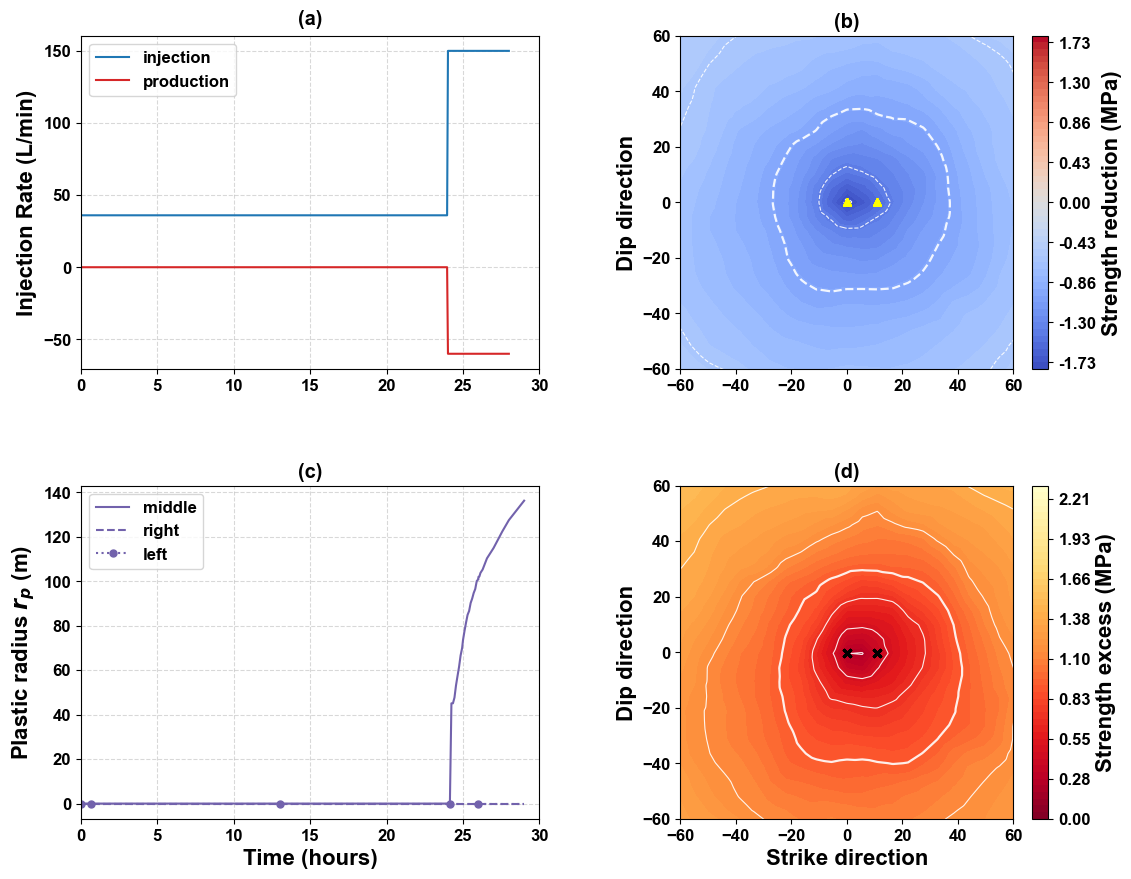

In [9]:
re_idx, re_t, counts = get_reactivation_time(F_df, 7)
be4_time = counts.index[re_idx-1]

# ----------------------------
# Figure layout (FIXED GRID)
# ----------------------------
fig = plt.figure(figsize=(12, 9))

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    wspace=0.12,
    hspace=0.35
)

fig.subplots_adjust(
    left=0.07,
    right=0.88,
    bottom=0.08,
    top=0.95
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])


# ----------------------------
# Styling helper
# ----------------------------
def style(ax):
    ax.grid(True, color='gray', alpha=0.3, linestyle='--')
    ax.tick_params(direction='out')


def style_field(ax):
    # NO grid for colormap panels
    ax.tick_params(direction='out')

# ============================
# (a) Injection protocols
# ============================
ax = ax0

ax.plot(t1, injection_rate_1, label="injection", color='tab:blue')
ax.plot(t1, injection_rate_2, label="production", color='tab:red')

ax.set_title("(a)", pad=8)
# ax.set_xlabel("Time (hours)")
ax.set_ylabel("Injection Rate (L/min)")
ax.legend()
ax.set_xlim(0, 30)
style(ax)


# ============================
# (b) Slipping radius
# ============================
ax = ax2

ax.plot(ra_times, np.sqrt(ra_intem / np.pi),
        color=cm.Purples(0.7), label="middle")

ax.plot(ra_times, np.sqrt(ra_inter / np.pi),
        color=cm.Purples(0.7), linestyle="--", label="right")

ax.plot(ra_times, np.sqrt(ra_intel / np.pi),
        color=cm.Purples(0.7), linestyle=":", marker='o', markevery=20, markersize =5, label="left")

ax.set_xlim(0, 30)
ax.set_xlabel("Time (hours)")
ax.set_ylabel('Plastic radius $r_p$ (m)')
ax.set_title('(c)')
ax.legend(loc="upper left")
style(ax)


# ============================
# (c) Stress field
# ============================
ax = ax1

y_grid, z_grid, ST = compute_ST_interp(lay=7, time_val=be4_time)
Z_plot = ST / 1e6

levels = np.linspace(-1.8, 1.8, 51)
levels_c = np.linspace(-1.8, 1.8, 10)
linewidths = [0.8] * len(levels_c)
linewidths[2] = 1.6

cf = ax.contourf(y_grid, z_grid, Z_plot,
                 levels=levels, cmap="coolwarm")

cs = ax.contour(y_grid, z_grid, Z_plot,
                levels=levels_c, colors="white", alpha=0.9, linewidths=linewidths,)

# ax.clabel(cs, inline=True, fontsize=5, fmt="%.2f")

# scatter points
ax.scatter(F_df.loc[F_df['ELEM'] == 'ASX79', 'Y'],
           F_df.loc[F_df['ELEM'] == 'ASX79', 'Z'],
           color='yellow', s=25, marker='^', zorder=10)

ax.scatter(F_df.loc[F_df['ELEM'] == 'ASY25', 'Y'],
           F_df.loc[F_df['ELEM'] == 'ASY25', 'Z'],
           color='yellow', s=25, marker='^', zorder=10)

ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_box_aspect(1)
ax.set_title('(b)')

# ax.set_xlabel("Strike direction")
ax.set_ylabel("Dip direction")

style_field(ax)

cbar1 = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar1.set_label("Strength reduction (MPa)")
cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# ============================
# (d) Stress difference
# ============================
ax = ax3

y_grid, z_grid, ST = compute_ST_diff_interp(
    lay=6,
    time_val=be4_time
)

Z_plot = ST / 1e6

levels = np.linspace(0, 2.3, 51)
levels_c = np.linspace(0, 2.3, 11)

linewidths = [0.8] * len(levels_c)
linewidths[4] = 1.6

cf = ax.contourf(y_grid, z_grid, Z_plot,
                 levels=levels, cmap="YlOrRd_r")

cs = ax.contour(y_grid, z_grid, Z_plot,
                levels=levels_c,
                colors="white",
                linewidths=linewidths,
                alpha=0.9)

# ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

ax.scatter(F_df.loc[F_df['ELEM'] == 'AU565', 'Y'],
           F_df.loc[F_df['ELEM'] == 'AU565', 'Z'],
           color='k', s=30, marker='x')

ax.scatter(F_df.loc[F_df['ELEM'] == 'AU611', 'Y'],
           F_df.loc[F_df['ELEM'] == 'AU611', 'Z'],
           color='k', s=30, marker='x')

ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_box_aspect(1)
ax.set_title('(d)')
ax.set_xlabel("Strike direction")
ax.set_ylabel("Dip direction")

style_field(ax)

cbar2 = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar2.set_label("Strength excess (MPa)")
cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))



# ----------------------------
# Final alignment polish
# ----------------------------
fig.align_ylabels([ax0, ax2])
fig.align_xlabels([ax2, ax3])

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig9.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

# Supporting Information (figures)

## Fig.S1 Shear stress of heterogeneous faults 

In [3]:
# read data
base_path_hete_np = (DATA_DIR / '03_heterf_np')
flac_file_hete_np = base_path_hete_np / 'F_clean.parquet'
F_df_hete_np = pd.read_parquet(flac_file_hete_np, engine='pyarrow')

In [4]:
middle_df = F_df_hete_np[F_df_hete_np['ROCK']==7]
counts = (middle_df['Strain_P'] > 0).groupby(middle_df['Time']).sum()
arr = counts.values

nonzero_mask = arr > 2
if nonzero_mask.any():
    reactivation_idx = np.argmax(nonzero_mask)
    reactivation_time = counts.index[reactivation_idx]
    reactivation_value = arr[reactivation_idx]
else:
    reactivation_time = None
    reactivation_value = 0

print(reactivation_idx)
print(reactivation_time)

be4_time = counts.index[reactivation_idx-1]

23
2822.0


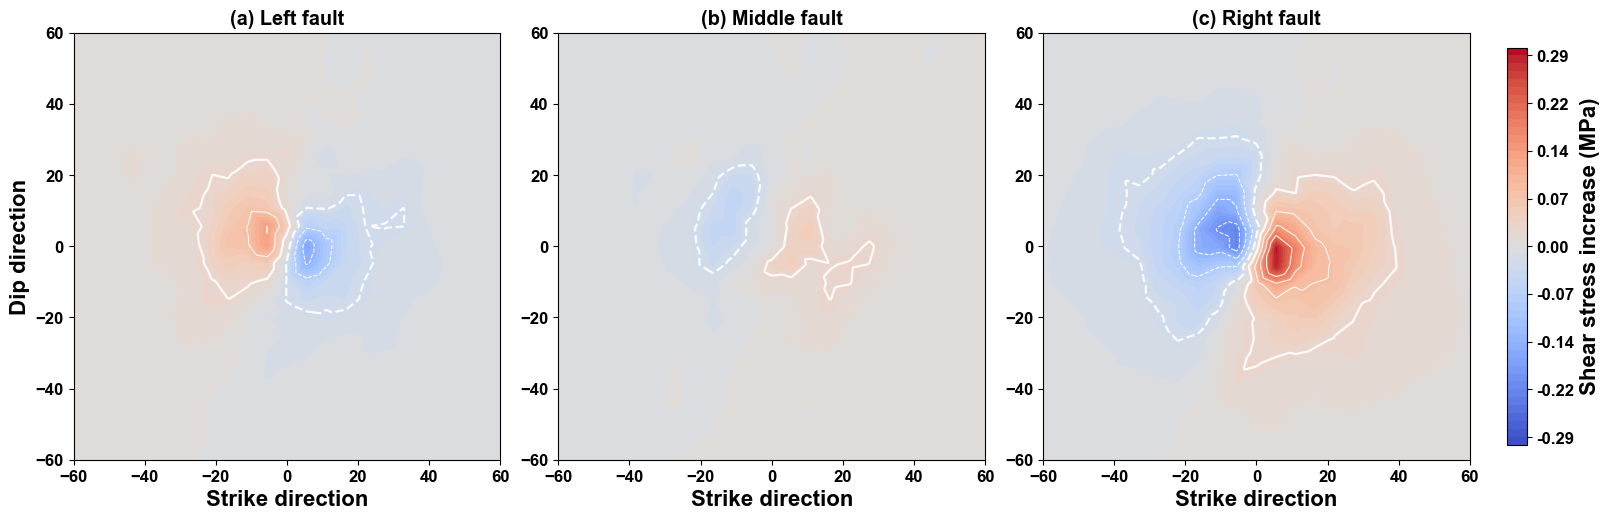

In [5]:
# -----------------------------
# helper
# -----------------------------
def compute_ST_interp(F_df, lay, time_val, n_grid=1000):
    F = F_df[F_df['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)
    sub0 = F[F['Time'] == 0].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = (
        sub['Shear_Stress(Pa)'].to_numpy()
        - sub0['Shear_Stress(Pa)'].to_numpy()
    ) / 1e6
 
    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid


# -----------------------------
# prepare datasets
# -----------------------------
faults = [
    (5, "Left fault"),
    (7, "Middle fault"),
    (6, "Right fault"),
]

plot_data = []

for rock_id, title in faults:
    y_grid, z_grid, ST = compute_ST_interp(
        F_df_hete_np,
        lay=rock_id,
        time_val=be4_time
    )

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })


# -----------------------------
# contour levels
# -----------------------------
levels = np.linspace(-0.2, 0.2, 8) # for make the line bolder
linewidths = [0.8] * len(levels)
linewidths[3] = 1.6
linewidths[4] = 1.6

filled_levels = np.linspace(-0.3, 0.3, 51)
# filled_levels = np.linspace(-0.165, 0.165, 51) # for the cases with pre-conditioning

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

labels = ["(a)", "(b)", "(c)"]

for i, (ax, item) in enumerate(zip(axes, plot_data)):
# for ax, item in zip(axes, plot_data):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"]
    title = item["title"]

    if title == "Left fault":
        ax.set_ylabel("Dip direction")

    # filled contours using OWN grid
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z,
        levels=filled_levels,
        cmap="coolwarm"
    )

    # contour lines using OWN grid
    cs = ax.contour(
        y_grid,
        z_grid,
        Z,
        levels=levels,
        colors="white",
        linewidths=linewidths,
        alpha=0.9
    )

    # label only bold contours
    label_levels = [levels[3], levels[4]]
    fmt_dict = {
        lv: f"{lv:.2f}"
        for lv in label_levels
    }
    # ax.clabel(cs, levels=label_levels, fmt=fmt_dict, colors='black', fontsize=6, inline=False, inline_spacing=0.1)

    # ax.set_title(title)
    ax.set_title(f"{labels[i]} {item['title']}")
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")


# -----------------------------
# shared colorbar
# -----------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.91, pad=0.02)
cbar.set_label("Shear stress increase (MPa)")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig_S1.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()

## Fig.S2 Slip tendency of all three faults in homogeneous fualts

In [3]:
def slip_tendency(shear, normal, mu_fric=0.21, cohesion=2e6):
    return shear / (np.tan(np.deg2rad(21)) * normal + cohesion)


def compute_ST_interp(F_df, lay, time_val, n_grid=1000):
    F = F_df[F_df['ROCK'] == lay]

    sub = F[F['Time'] == time_val].reset_index(drop=True)

    y = sub['Y'].to_numpy()
    z = sub['Z'].to_numpy()

    ST = slip_tendency(
        sub['Shear_Stress(Pa)'],
        sub['Normal_Stress(Pa)']
    )

    # Build grid for THIS layer
    y_grid, z_grid = np.meshgrid(
        np.linspace(y.min(), y.max(), n_grid),
        np.linspace(z.min(), z.max(), n_grid)
    )

    # Interpolate onto own grid
    ST_grid = griddata(
        (y, z),
        ST,
        (y_grid, z_grid),
        method='linear'
    )

    return y_grid, z_grid, ST_grid



In [4]:
# reading the data
# File paths
base_path = (DATA_DIR / '02_homogf')
flac_file = base_path / 'F_clean.parquet'
F_df = pd.read_parquet(flac_file, engine='pyarrow')

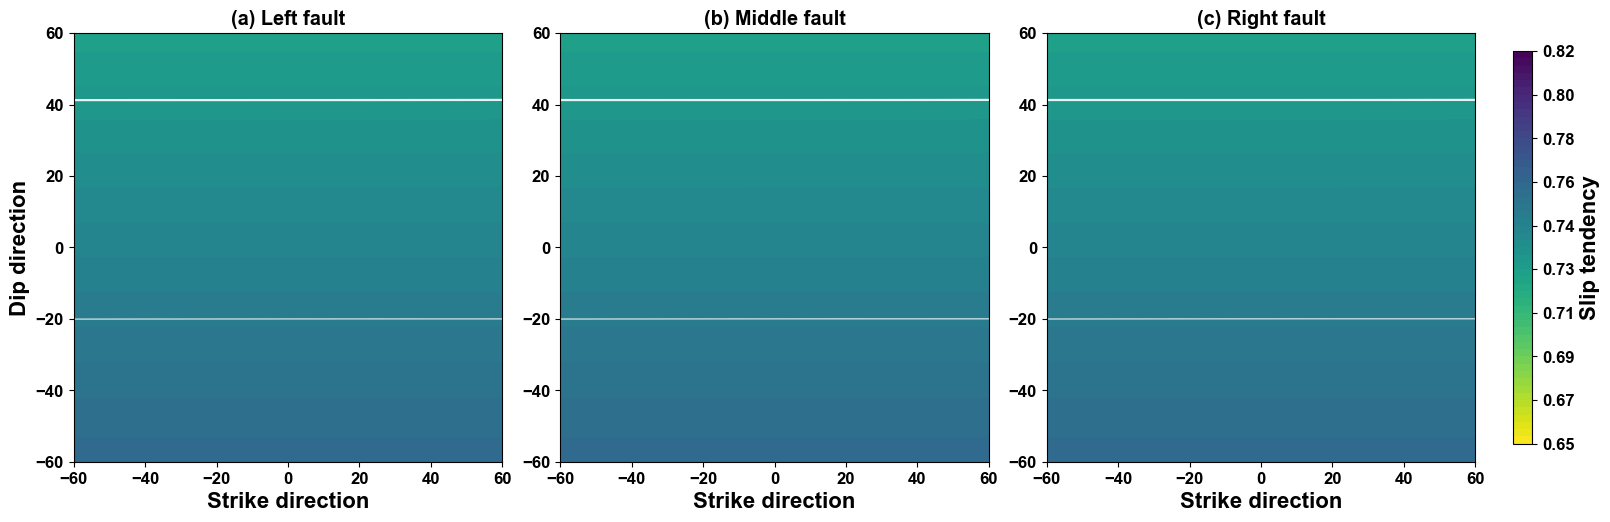

In [5]:

# -----------------------------
# prepare datasets
# -----------------------------
faults = [
    (5, "(a) Left fault"),
    (7, "(b) Middle fault"),
    (6, "(c) Right fault"),
]

plot_data = []

for rock_id, title in faults:
    y_grid, z_grid, ST = compute_ST_interp(
        F_df,
        lay=rock_id,
        time_val=0 # be4_time
    )

    plot_data.append({
        "title": title,
        "y_grid": y_grid,
        "z_grid": z_grid,
        "ST": ST
    })

    if rock_id == 7: ST_ref=ST


# -----------------------------
# contour levels
# -----------------------------
levels = np.linspace(0.65, 0.85, 11) # for make the line bolder
linewidths = [0.8] * len(levels)
linewidths[3] = 1.6
linewidths[4] = 1.6

filled_levels = np.linspace(0.65, 0.82, 55)
# filled_levels = np.linspace(-0.165, 0.165, 51) # for the cases with pre-conditioning

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True
)

for ax, item in zip(axes, plot_data):

    y_grid = item["y_grid"]
    z_grid = item["z_grid"]
    Z = item["ST"] # - ST_ref
    title = item["title"]

    if title == "(a) Left fault":
        ax.set_ylabel("Dip direction")

    # filled contours using OWN grid
    cf = ax.contourf(
        y_grid,
        z_grid,
        Z,
        levels=filled_levels,
        cmap="viridis_r"
    )

    # contour lines using OWN grid
    cs = ax.contour(
        y_grid,
        z_grid,
        Z,
        levels=levels,
        colors="white",
        linewidths=linewidths,
        alpha=0.9
    )

    # label only bold contours
    label_levels = [levels[3], levels[4]]
    fmt_dict = {
        lv: f"{lv:.2f}"
        for lv in label_levels
    }
    # ax.clabel(cs, levels=levels, colors='white', fontsize=5, inline=True)

    ax.set_title(title)
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")
    ax.set_xlabel("Strike direction")

# -----------------------------
# shared colorbar
# -----------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.91, pad=0.02)
cbar.set_label("Slip tendency")
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

if SAVE_FIG:
    save_path = FIG_DIR / 'Fig_S2.pdf'

    fig.savefig(
        save_path,
        format="pdf",
        bbox_inches="tight",
        dpi=600
    )

plt.show()